# Project Overview

## Problem Statement

Buying or selling a used car can be difficult because its price depends on many different factors such as the brand, model, age, mileage, engine capacity, location, fuel type, transmission, and overall condition. Unlike new cars, used cars do not have a fixed price, and similar vehicles can have significantly different prices depending on these factors.

In this project, I want to build a deep learning model that can predict the price of a used car based on its available features. Along with predicting the actual price, the model will also classify the car into a price tier such as Low, Medium, or High.

The main idea is to build a single model that can perform both tasks at the same time. This makes the project a good use case for the Functional API and multi task learning in Keras.

## Business Motivation

A used car marketplace can use a system like this to provide sellers with an estimated price for their vehicles and help buyers quickly understand whether a car falls into a low, medium, or high price range.

For example, instead of only showing an estimated price, a platform could also label a vehicle as a "Medium Price" car. This could make searching and filtering vehicles easier for users.

From a machine learning perspective, predicting the exact price and predicting its price category are related tasks. Both tasks depend on many of the same features, so it is interesting to see whether a shared neural network can learn useful information for both tasks simultaneously.

## Objectives

The main objectives of this project are:

1.  Perform data cleaning and exploratory data analysis on the used-car dataset.
    
2.  Identify and handle missing values and anomalous observations.
    
3.  Analyze numerical and categorical features and their relationship with car prices.
    
4.  Create a price-tier target from the original price variable.
    
5.  Establish baseline regression and classification models.
    
6.  Build a Multi-Input, Multi-Output neural network using the Keras Functional API.
    
7.  Use embeddings to represent categorical variables.
    
8.  Predict both car price and price tier using a shared neural network architecture.
    
9.  Evaluate the two outputs using appropriate regression and classification metrics.
    
10.  Experiment with different loss-weight combinations to study the trade-off between the two tasks.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/taeefnajib/bikroy-car-price-prediction/bikroy car prices kaggle.csv


In [2]:
# imports
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score, classification_report, accuracy_score, confusion_matrix, recall_score, precision_score,f1_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.models import Model
from keras.layers import *
from keras.utils import plot_model

# 2. Dataset

## Source

The dataset used in this project is the **Bikroy Car Price Prediction Dataset**, available on Kaggle.

Dataset: [Bikroy Car Price Prediction](https://www.kaggle.com/datasets/taeefnajib/bikroy-car-price-prediction)

The dataset contains information about used cars listed on Bikroy, an online marketplace. It provides a combination of numerical and categorical features, making it suitable for experimenting with a deep learning model that uses different input branches.

## Dataset Description

The dataset contains around 10,000 used car listings and includes information about different aspects of each vehicle, such as its brand, model, manufacturing year, mileage, engine capacity, location, fuel type, transmission, and condition.

The main target variable is `price`, which represents the listed price of the vehicle.

For this project, I will also create a second target called `price_tier`. This will divide the cars into three categories:

* Low
* Medium
* High

The price tiers will be created based on the distribution of prices in the training data rather than using arbitrary fixed price thresholds. This will give me a classification target that can be learned alongside the price regression task.

I will not use every column available in the original dataset. Some columns, such as listing IDs, URLs, titles, or descriptions, are not directly useful for the tabular model being developed here. I will select the features that are relevant to the prediction problem and can be meaningfully processed using numerical layers and categorical embeddings.

## Feature Description

The main features I plan to use are divided into numerical and categorical features.

### Numerical Features

| Feature             | Description                                |
| ------------------- | ------------------------------------------ |
| `year`              | Manufacturing year of the vehicle          |
| `registration_year` | Year in which the vehicle was registered   |
| `engine_capacity`   | Engine capacity of the vehicle             |
| `mileage`           | Distance travelled by the vehicle          |
| `vehicle_age`       | Feature engineered from the vehicle's year |

The `vehicle_age` feature will be derived from the year of the vehicle and will provide the model with a more direct representation of how old the car is.

### Categorical Features

| Feature        | Description                                               |
| -------------- | --------------------------------------------------------- |
| `brand`        | Manufacturer or brand of the vehicle                      |
| `model`        | Specific model of the vehicle                             |
| `edition`      | Edition or variant of the vehicle                         |
| `location`     | Location where the vehicle is listed                      |
| `body_type`    | Type of vehicle body, such as sedan, SUV, hatchback, etc. |
| `transmission` | Type of transmission used by the vehicle                  |
| `fuel_type`    | Type of fuel used by the vehicle                          |
| `condition`    | Overall condition of the vehicle at the time of listing   |

The categorical features will first be converted into integer representations and then passed through separate embedding layers. This allows the model to learn a numerical representation for different categories instead of treating them as completely independent values.

### Target Variables

| Target       | Type           | Description                                         |
| ------------ | -------------- | --------------------------------------------------- |
| `price`      | Regression     | Actual listed price of the vehicle                  |
| `price_tier` | Classification | Price category of the vehicle: Low, Medium, or High |

The final model will therefore have two outputs: one for predicting the actual price and another for predicting the price tier.


In [3]:
df=pd.read_csv('/kaggle/input/datasets/taeefnajib/bikroy-car-price-prediction/bikroy car prices kaggle.csv')

In [4]:
df.shape

(10042, 19)

In [5]:
df.sample(5)

,area,body_type,brand,condition,engine_capacity,Fuel type:,km_run,listing_title,model,posted_on,price,reg_year,sold_by,subarea,transmission,additional_info,url,views,man_year
1734,Khulna\n59\nviews,MPV,Toyota,Reconditioned,"1,800 cc","Petrol, Hybrid, Octane","26,120 km",Toyota Esquire Gi Premium Black 2019,Esquire,24/07/2025 16:15,"Tk 3,550,000",NaN,Company,Khulna Sadar,Automatic,Gi Premium Black,https://bikroy.com/en/ad/toyota-esquire-gi-pre...,59.0,2019
8832,Chattogram\n815\nviews,Saloon,Toyota,Used,"1,500 cc","Petrol, CNG, Octane","68,000 km",Toyota Premio G SUPERIOR PKG 2010,Premio,28/07/2025 11:18,"Tk 2,150,000",2015.0,Company,Bandar,Automatic,G SUPERIOR PKG,https://bikroy.com/en/ad/toyota-premio-g-super...,815.0,2010
8535,Dhaka\n20\nviews,SUV / 4x4,Honda,Reconditioned,"1,500 cc","Hybrid, Octane","80,000 km",Honda Vezel RS Sensing 2020,Vezel,28/07/2025 11:34,"Tk 3,100,000",NaN,Company,Gulshan,Automatic,RS Sensing,https://bikroy.com/en/ad/honda-vezel-rs-sensin...,20.0,2020
3525,Chattogram\n4613\nviews,SUV / 4x4,Proton,Used,"1,500 cc","Petrol, Hybrid, Octane","7,000 km",Proton X90 7SEAT SUNROOF 2024,Other Model,26/07/2025 21:31,"Tk 4,450,000",2024.0,Company,Khulshi,Automatic,X90 7SEAT SUNROOF,https://bikroy.com/en/ad/proton-x90-7seat-sunr...,4613.0,2024
8413,Chattogram\n34\nviews,MPV,Toyota,Reconditioned,"2,000 cc",Octane,"182,000 km",Toyota Noah X SMART NON HYB 2020,Noah,28/07/2025 11:41,"Tk 3,749,994",NaN,Company,Agrabad,Automatic,X SMART NON HYB,https://bikroy.com/en/ad/toyota-noah-x-smart-n...,34.0,2020


In [6]:
df.rename(columns={'Fuel type:': 'fuel_type'}, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10042 entries, 0 to 10041
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             10042 non-null  object 
 1   body_type        8864 non-null   object 
 2   brand            10042 non-null  object 
 3   condition        10042 non-null  object 
 4   engine_capacity  10042 non-null  object 
 5   fuel_type        10042 non-null  object 
 6   km_run           10042 non-null  object 
 7   listing_title    10042 non-null  object 
 8   model            10042 non-null  object 
 9   posted_on        10042 non-null  object 
 10  price            10042 non-null  object 
 11  reg_year         2292 non-null   float64
 12  sold_by          10042 non-null  object 
 13  subarea          10042 non-null  object 
 14  transmission     10042 non-null  object 
 15  additional_info  9780 non-null   object 
 16  url              10042 non-null  object 
 17  views       

In [8]:
df.isnull().sum()

area                  0
body_type          1178
brand                 0
condition             0
engine_capacity       0
fuel_type             0
km_run                0
listing_title         0
model                 0
posted_on             0
price                 0
reg_year           7750
sold_by               0
subarea               0
transmission          0
additional_info     262
url                   0
views               975
man_year              0
dtype: int64

# Data Cleaning

The dataset initially contained several columns that were not useful for the predictive modeling task, including listing-specific metadata and information that could introduce noise.

The following preprocessing steps were performed:

1.  Removed irrelevant columns.
    
2.  Removed duplicate records.
    
3.  Cleaned inconsistent text representations in categorical columns.
    
4.  Converted relevant numerical columns to appropriate numerical data types.
    
5.  Examined missing values.
    
6.  Removed observations with invalid values such as zero price or zero engine capacity where appropriate.
    
7.  Investigated unusual observations in numerical variables.
    
8.  Analyzed outliers using the IQR method.
    
9.  Removed observations identified as unrealistic or unsuitable for the modeling task.
    

After preprocessing, the resulting dataset was used for exploratory analysis and model development.

In [9]:
df.drop(columns=['listing_title','additional_info','url','reg_year','views'],inplace=True)

In [10]:
df.head()

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,posted_on,price,sold_by,subarea,transmission,man_year
0,Dhaka\n1797\nviews,Saloon,Toyota,Used,"2,000 cc","CNG, Octane","116,000 km",Noah,23/07/2025 12:56,"Tk 2,100,000",Individual,Uttara,Automatic,2011
1,Dhaka\n1171\nviews,MPV,Toyota,New,"1,800 cc","Petrol, Hybrid, Octane","35,200 km",Noah,23/07/2025 12:53,"Tk 4,350,000",Company,Baridhara,Automatic,2022
2,Dhaka\n9550\nviews,SUV / 4x4,SsangYong,Used,"1,500 cc","Petrol, Octane","20,000 km",Korando,23/07/2025 12:43,"Tk 3,300,000",Individual,Gulshan,Automatic,2020
3,Dhaka\n2794\nviews,MPV,Toyota,Used,"2,000 cc","CNG, Octane","66,000 km",Noah,23/07/2025 12:26,"Tk 2,050,000",Individual,Dhanmondi,Automatic,2010
4,Dhaka\n9\nviews,Saloon,Toyota,Used,"1,500 cc","Petrol, CNG","88,000 km",Probox,23/07/2025 12:22,"Tk 710,000",Company,Mirpur,Automatic,2004


In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(10041, 14)

In [14]:
df['area']=df['area'].str.split('\n').str[0]
df['body_type']=df['body_type'].str.split('/').str[0]

In [15]:
df['engine_capacity'] = df['engine_capacity'].str.extract(r'(\d[\d,]*)').replace(',', '', regex=True)
df['km_run'] = df['km_run'].str.extract(r'(\d[\d,]*)').replace(',', '', regex=True)
df['price'] = df['price'].str.extract(r'(\d[\d,]*)').replace(',', '', regex=True)


In [16]:
df.head()

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,posted_on,price,sold_by,subarea,transmission,man_year
0,Dhaka,Saloon,Toyota,Used,2000,"CNG, Octane",116000,Noah,23/07/2025 12:56,2100000,Individual,Uttara,Automatic,2011
1,Dhaka,MPV,Toyota,New,1800,"Petrol, Hybrid, Octane",35200,Noah,23/07/2025 12:53,4350000,Company,Baridhara,Automatic,2022
2,Dhaka,SUV,SsangYong,Used,1500,"Petrol, Octane",20000,Korando,23/07/2025 12:43,3300000,Individual,Gulshan,Automatic,2020
3,Dhaka,MPV,Toyota,Used,2000,"CNG, Octane",66000,Noah,23/07/2025 12:26,2050000,Individual,Dhanmondi,Automatic,2010
4,Dhaka,Saloon,Toyota,Used,1500,"Petrol, CNG",88000,Probox,23/07/2025 12:22,710000,Company,Mirpur,Automatic,2004


In [17]:
df[['engine_capacity','km_run','price']] = df[['engine_capacity','km_run','price']].astype(int)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10041 entries, 0 to 10041
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   area             10041 non-null  object
 1   body_type        8863 non-null   object
 2   brand            10041 non-null  object
 3   condition        10041 non-null  object
 4   engine_capacity  10041 non-null  int64 
 5   fuel_type        10041 non-null  object
 6   km_run           10041 non-null  int64 
 7   model            10041 non-null  object
 8   posted_on        10041 non-null  object
 9   price            10041 non-null  int64 
 10  sold_by          10041 non-null  object
 11  subarea          10041 non-null  object
 12  transmission     10041 non-null  object
 13  man_year         10041 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 1.1+ MB


## Handling Invalid Values

In [19]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area,10041,16,Dhaka,6299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body_type,8863,7,Saloon,3050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,10041,32,Toyota,8826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,10041,3,Reconditioned,7644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_capacity,10041.0,NaN,NaN,NaN,1778.399861,384.080739,0.0,1500.0,1800.0,2000.0,5700.0
fuel_type,10041,49,"Petrol, Hybrid, Octane",2455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
km_run,10041.0,NaN,NaN,NaN,62566.303057,43346.031053,0.0,40400.0,60413.0,79546.0,1000000.0
model,10041,188,Axio,1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
posted_on,10041,1050,24/07/2025 15:58,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,10041.0,NaN,NaN,NaN,4124076.303157,5445836.491774,0.0,2500000.0,3400000.0,4350000.0,275000000.0


In [20]:
print("Invalid price:", (df['price'] <= 0).sum())
print("Invalid engine capacity:", (df['engine_capacity'] <= 0).sum())

Invalid price: 19
Invalid engine capacity: 3


In [21]:
df = df[(df['price'] > 0) & (df['engine_capacity'] > 0)]

In [22]:
df.reset_index(drop=True, inplace=True)

In [23]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area,10019,16,Dhaka,6279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body_type,8842,7,Saloon,3030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,10019,32,Toyota,8807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,10019,3,Reconditioned,7624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_capacity,10019.0,NaN,NaN,NaN,1779.460325,383.075372,125.0,1500.0,1800.0,2000.0,5700.0
fuel_type,10019,49,"Petrol, Hybrid, Octane",2455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
km_run,10019.0,NaN,NaN,NaN,62493.735602,42555.171868,0.0,40382.5,60413.0,79548.0,1000000.0
model,10019,188,Axio,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
posted_on,10019,1049,24/07/2025 16:57,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,10019.0,NaN,NaN,NaN,4107490.783511,5162280.118053,20832.0,2500000.0,3400000.0,4350000.0,275000000.0


## Handling Missing Values

In [24]:
df.isnull().sum()

area                  0
body_type          1177
brand                 0
condition             0
engine_capacity       0
fuel_type             0
km_run                0
model                 0
posted_on             0
price                 0
sold_by               0
subarea               0
transmission          0
man_year              0
dtype: int64

In [25]:
df['body_type'] = df['body_type'].fillna('Unknown')

## Handling Rare Categories of Categorical Columns

In [26]:
print("\nUnique values in Categorical Columns:")
print(df.select_dtypes(include='object').nunique().sort_values(ascending=False))


Unique values in Categorical Columns:
posted_on       1049
model            188
subarea          114
fuel_type         49
brand             32
area              16
body_type          8
condition          3
transmission       3
sold_by            2
dtype: int64


In [27]:
def combine_rare_categories(df, column, min_count=20):
    counts = df[column].value_counts()
    rare = counts[counts < min_count].index
    df[column] = df[column].replace(rare, 'Other')
    return df

In [28]:
counts = df['model'].value_counts()
counts[counts >= 81].count()

np.int64(24)

In [29]:
df = combine_rare_categories(df,'model',82)

In [30]:
counts = df['subarea'].value_counts()
counts[counts>30].count()

np.int64(19)

In [31]:
df = combine_rare_categories(df,'subarea',31)

In [32]:
df['fuel_type'].value_counts()

fuel_type
Petrol, Hybrid, Octane                       2455
Hybrid                                       1855
Petrol, Octane                               1704
Octane                                       1331
Hybrid, Octane                               1122
CNG, Octane                                   616
Petrol                                        266
Octane, LPG                                   205
Petrol, Hybrid, Octane, Other fuel type        93
Diesel                                         80
Petrol, CNG, Octane                            69
Octane, Other fuel type                        32
Petrol, CNG                                    19
CNG                                            19
Petrol, Octane, LPG                            17
LPG                                            14
Petrol, LPG                                    13
Petrol, Octane, Other fuel type                12
Petrol, Hybrid                                 10
Hybrid, Electric                        

In [33]:
df = combine_rare_categories(df,'fuel_type',31)

In [34]:
df['brand'].value_counts()

brand
Toyota           8807
Honda             518
Nissan            232
Mitsubishi        124
Lexus              79
BMW                54
Mazda              31
Mercedes-Benz      30
Hyundai            26
Range Rover        22
Proton             14
Audi               12
Suzuki             12
Haval              10
DFSK                8
Land Rover          6
Ford                6
Kia                 5
Subaru              3
Other brand         3
Volvo               2
Tata                2
Chery               2
MG                  2
Maserati            2
SsangYong           1
Great Wall          1
Mahindra            1
BAIC                1
Akij                1
Porsche             1
Daihatsu            1
Name: count, dtype: int64

In [35]:
df = combine_rare_categories(df,'brand',10)

In [36]:
df['area'].value_counts()

area
Dhaka                  6279
Khulna                 2462
Chattogram             1163
Chattogram Division      28
Sylhet                   27
Dhaka Division           16
Rajshahi Division         8
Barishal                  8
Rajshahi                  6
Rangpur                   5
Khulna Division           5
Sylhet Division           4
Mymensingh                3
Mymensingh Division       3
Rangpur Division          1
Barishal Division         1
Name: count, dtype: int64

In [37]:
df = combine_rare_categories(df,'area',10)

# Feature Engineering

## Creating a new column called 'cars_age' - For how many years card is used

In [38]:
df['posted_on']=pd.to_datetime(df['posted_on'],format='%d/%m/%Y %H:%M')
df['year_posted_on']=df['posted_on'].dt.year
df['cars_age'] = df['year_posted_on'] - df['man_year']

In [39]:
df.drop(columns=['posted_on','year_posted_on','man_year'],inplace=True)

In [40]:
df.head()

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age
0,Dhaka,Saloon,Toyota,Used,2000,"CNG, Octane",116000,Noah,2100000,Individual,Uttara,Automatic,14
1,Dhaka,MPV,Toyota,New,1800,"Petrol, Hybrid, Octane",35200,Noah,4350000,Company,Baridhara,Automatic,3
2,Dhaka,SUV,Other,Used,1500,"Petrol, Octane",20000,Other,3300000,Individual,Gulshan,Automatic,5
3,Dhaka,MPV,Toyota,Used,2000,"CNG, Octane",66000,Noah,2050000,Individual,Dhanmondi,Automatic,15
4,Dhaka,Saloon,Toyota,Used,1500,Other,88000,Other,710000,Company,Mirpur,Automatic,21


In [41]:
df[df['cars_age']==-1]

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age
8555,Khulna,Hatchback,Nissan,Used,1300,"Octane, LPG",100000,Other,750000,Individual,Other,Automatic,-1


In [42]:
df.drop(df.index[8574],inplace=True)

# Exploratory Data Analysis

## Numerical Feature Analysis

The numerical variables were analyzed using descriptive statistics, distribution plots, and relationship plots.

The distributions were found to be particularly right-skewed for some variables, especially `price` and `km_run`.

----------

## Categorical Feature Analysis

Categorical variables were analyzed using frequency distributions and visualizations.

Some categories occurred significantly less frequently than others. Rare categories were grouped into separate `Others` categories where appropriate for EDA and modeling, while ensuring that meaningful information was not unnecessarily removed.

In [43]:
df

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age
0,Dhaka,Saloon,Toyota,Used,2000,"CNG, Octane",116000,Noah,2100000,Individual,Uttara,Automatic,14
1,Dhaka,MPV,Toyota,New,1800,"Petrol, Hybrid, Octane",35200,Noah,4350000,Company,Baridhara,Automatic,3
2,Dhaka,SUV,Other,Used,1500,"Petrol, Octane",20000,Other,3300000,Individual,Gulshan,Automatic,5
3,Dhaka,MPV,Toyota,Used,2000,"CNG, Octane",66000,Noah,2050000,Individual,Dhanmondi,Automatic,15
4,Dhaka,Saloon,Toyota,Used,1500,Other,88000,Other,710000,Company,Mirpur,Automatic,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,Khulna,Saloon,Toyota,Reconditioned,1500,"Petrol, Octane",59000,Premio,5050000,Company,Khulna Sadar,Automatic,4
10015,Khulna,Hatchback,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",14670,Aqua,2050000,Company,Khulna Sadar,Automatic,5
10016,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",65055,Sienta,2950000,Company,Khulna Sadar,Automatic,4
10017,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Octane",171543,Sienta,2600000,Company,Khulna Sadar,Automatic,6


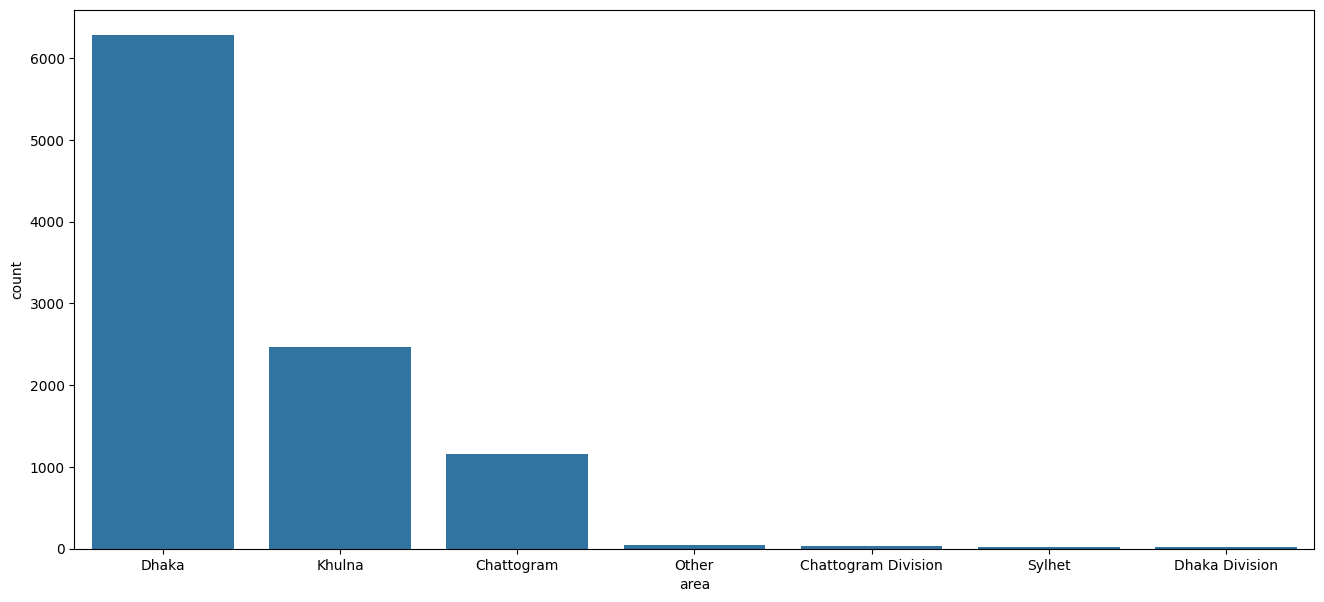

In [44]:
plt.figure(figsize=(16, 7))
sns.countplot(
    data=df,
    x='area',
    order=df['area'].value_counts().index
)
plt.show()

<Axes: ylabel='count'>

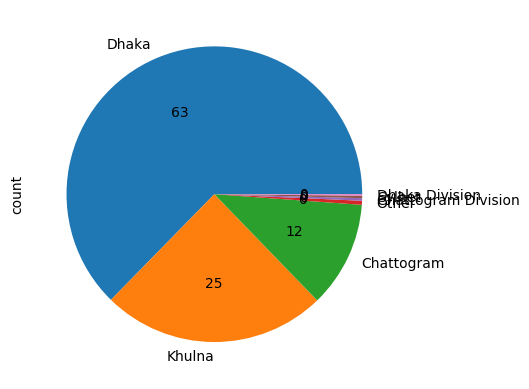

In [45]:
df['area'].value_counts().plot(kind='pie',autopct='%.0f')

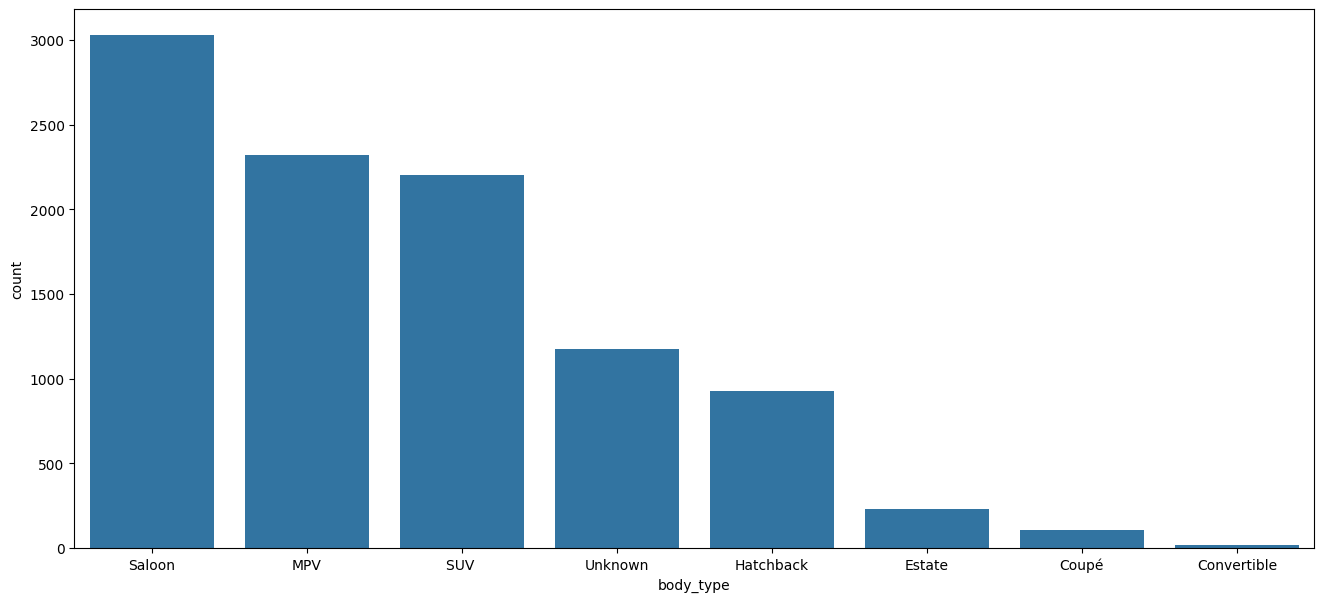

In [46]:
plt.figure(figsize=(16, 7))
sns.countplot(data=df,x='body_type')
plt.show()

<Axes: ylabel='count'>

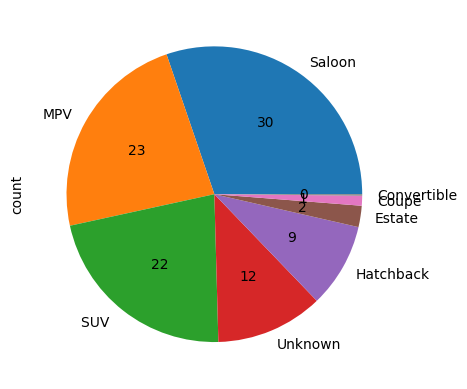

In [47]:
df['body_type'].value_counts().plot(kind='pie',autopct='%.0f')

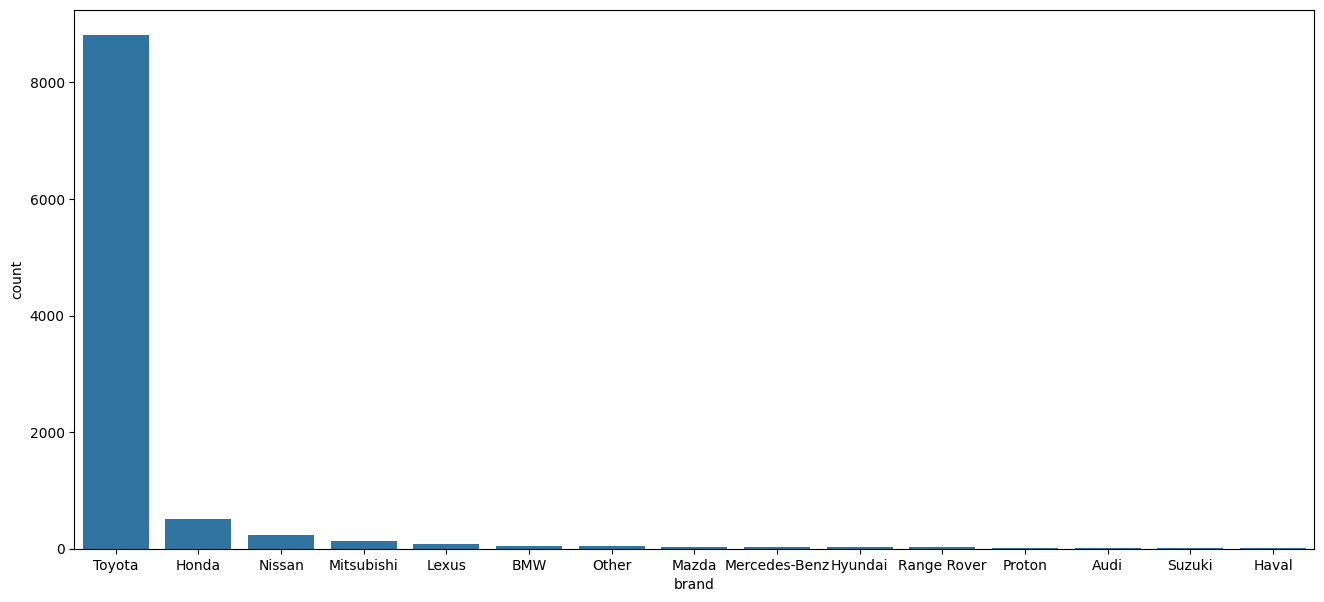

In [48]:
plt.figure(figsize=(16, 7))
sns.countplot(
    data=df,
    x='brand',
    order=df['brand'].value_counts().index
)

plt.show()

<Axes: ylabel='count'>

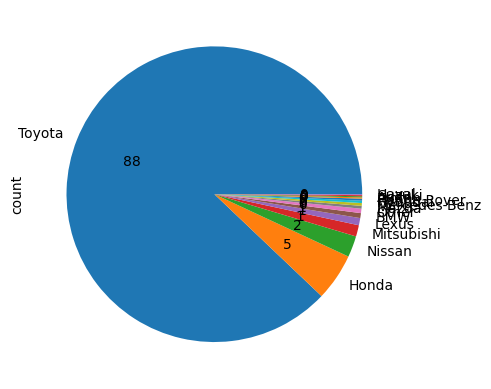

In [49]:
df['brand'].value_counts().plot(kind='pie',autopct='%.0f')

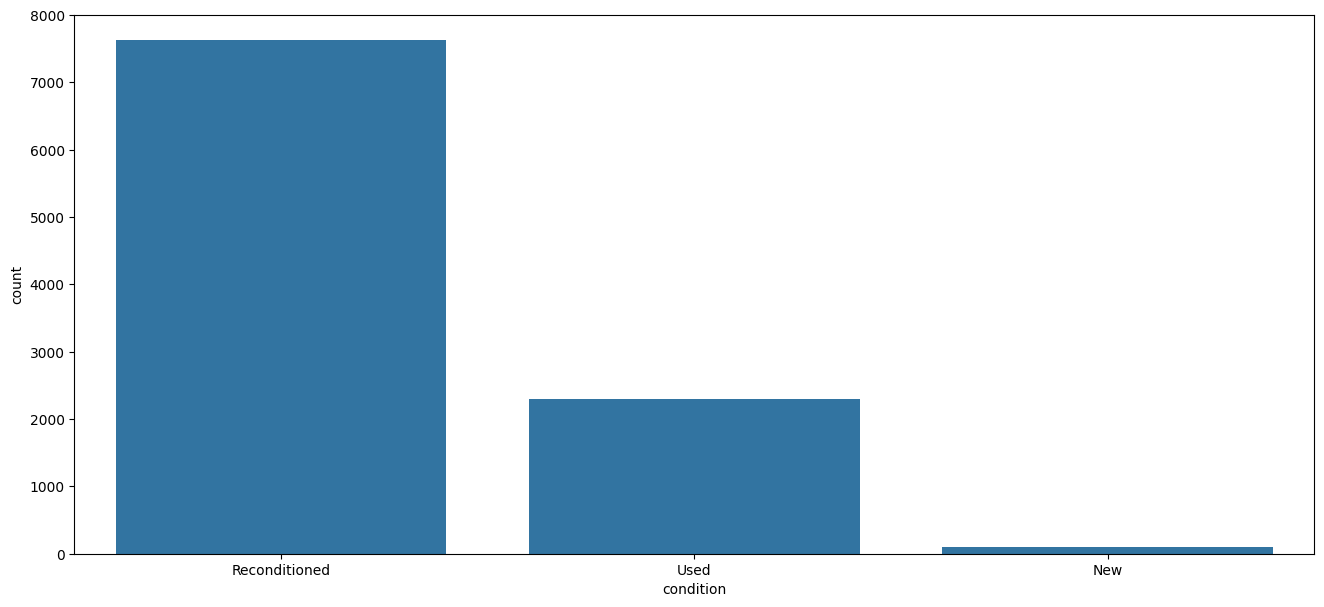

In [50]:
plt.figure(figsize=(16, 7))
sns.countplot(
    data=df,
    x='condition',
    order=df['condition'].value_counts().index
)

plt.show()

<Axes: ylabel='count'>

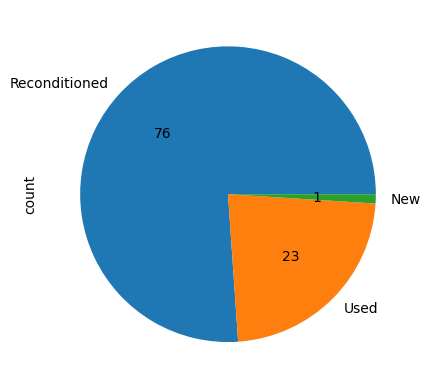

In [51]:
df['condition'].value_counts().plot(kind='pie',autopct='%.0f')

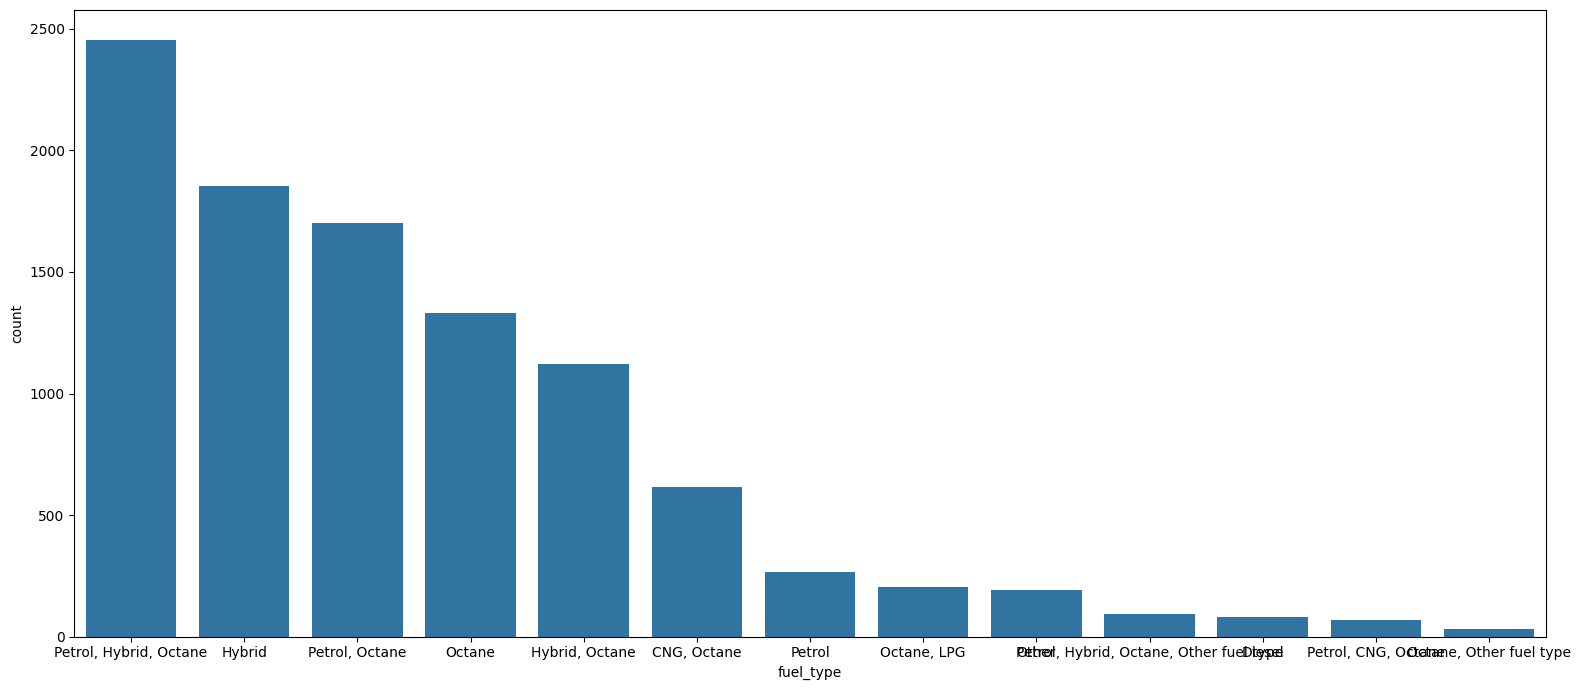

In [52]:
plt.figure(figsize=(16, 7))
sns.countplot(
    data=df,
    x='fuel_type',
    order=df['fuel_type'].value_counts().index
)
plt.tight_layout()
plt.show()

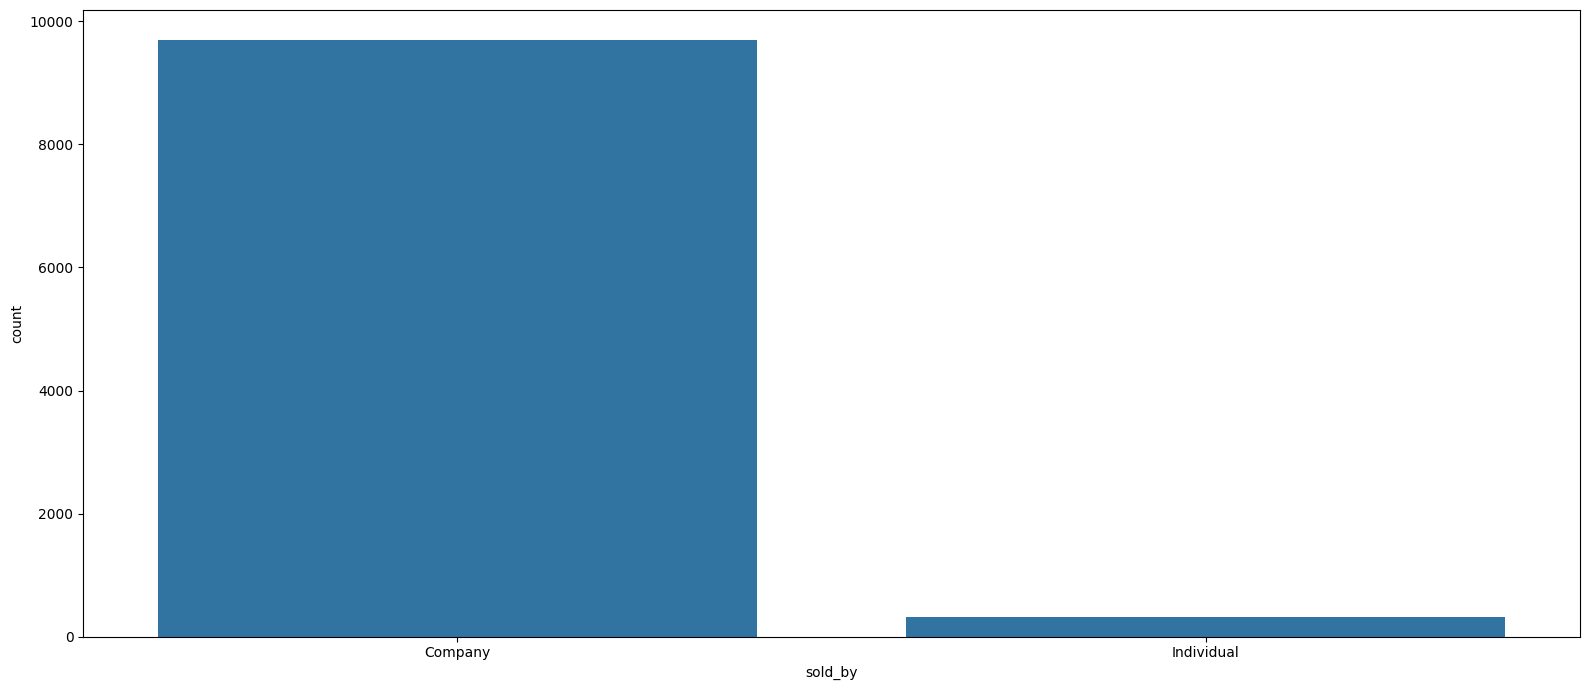

In [53]:
plt.figure(figsize=(16, 7))
sns.countplot(
    data=df,
    x='sold_by',
    order=df['sold_by'].value_counts().index
)
plt.tight_layout()
plt.show()

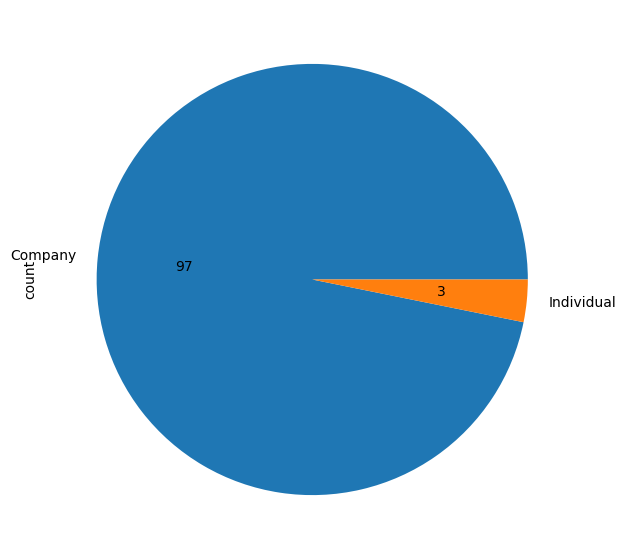

In [54]:
plt.figure(figsize=(16, 7))
df['sold_by'].value_counts().plot(kind='pie',autopct='%.0f')
plt.show()

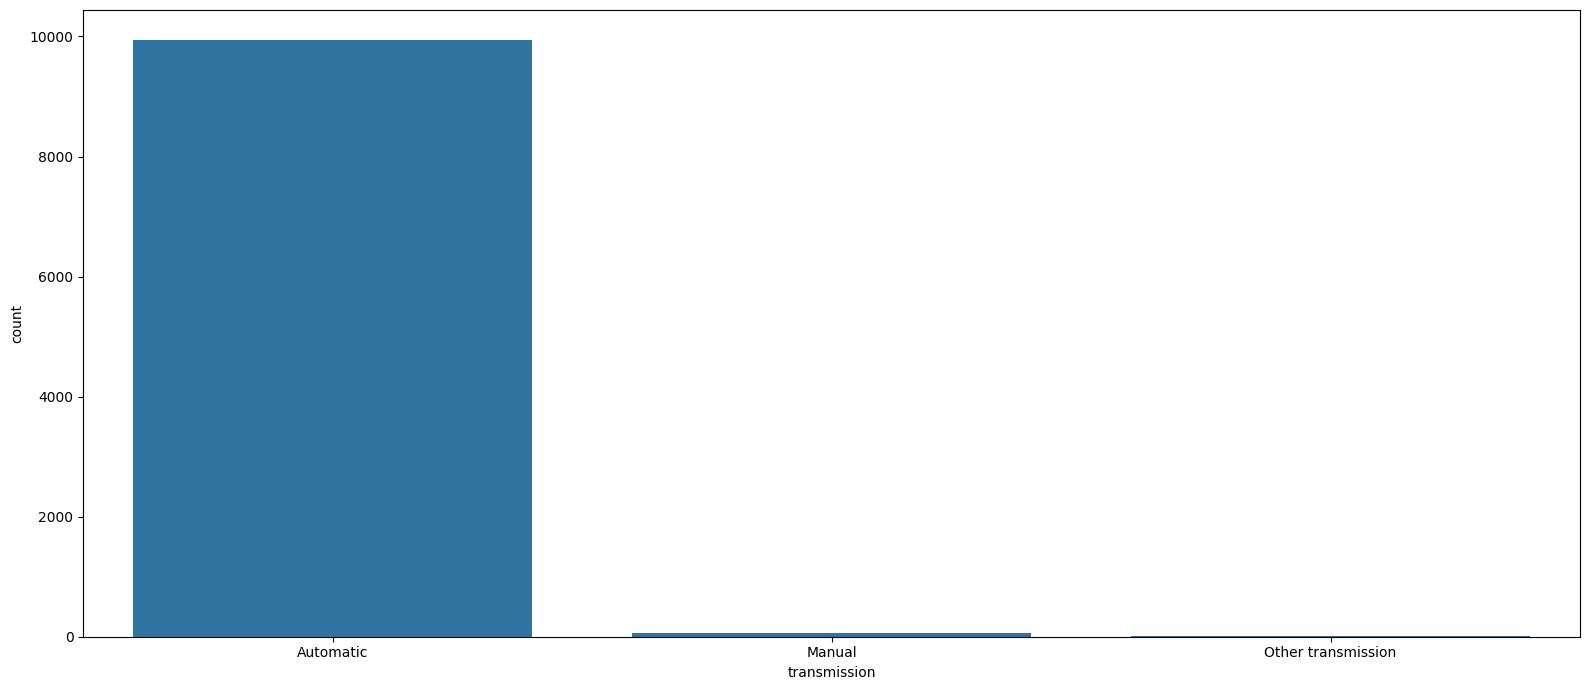

In [55]:
plt.figure(figsize=(16, 7))
sns.countplot(
    data=df,
    x='transmission',
    order=df['transmission'].value_counts().index
)
plt.tight_layout()
plt.show()

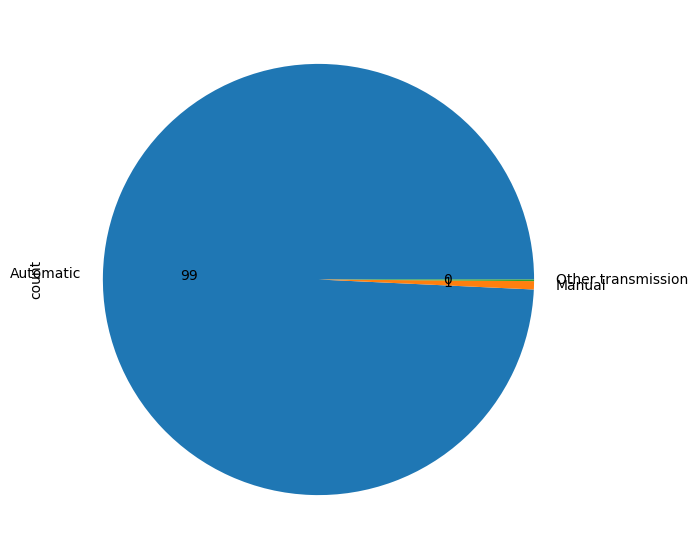

In [56]:
plt.figure(figsize=(16, 7))
df['transmission'].value_counts().plot(kind='pie',autopct='%.0f')
plt.show()

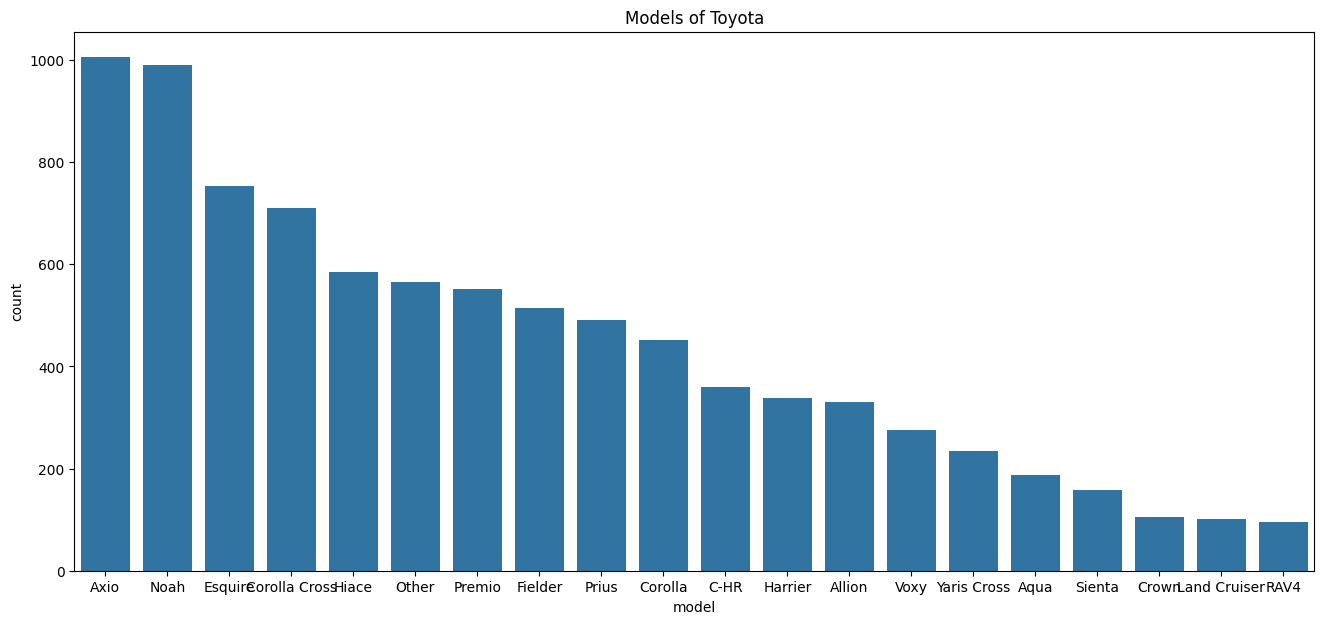

In [57]:
mask = df[df['brand'] == 'Toyota']
plt.figure(figsize=(16, 7))
plt.title('Models of Toyota')
sns.countplot(
    data=mask,
    x='model',
    order=mask['model'].value_counts().index
)

plt.show()

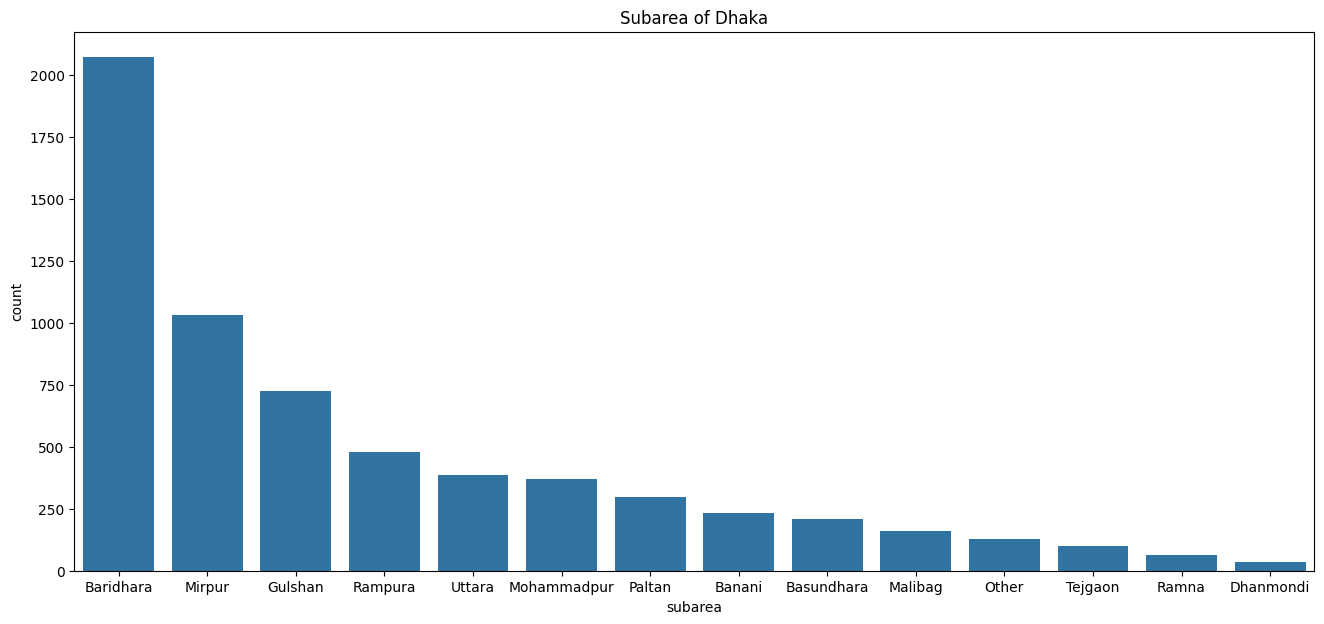

In [58]:
mask = df[df['area'] == 'Dhaka']
plt.figure(figsize=(16, 7))
plt.title('Subarea of Dhaka')
sns.countplot(
    data=mask,
    x='subarea',
    order=mask['subarea'].value_counts().index
)

plt.show()

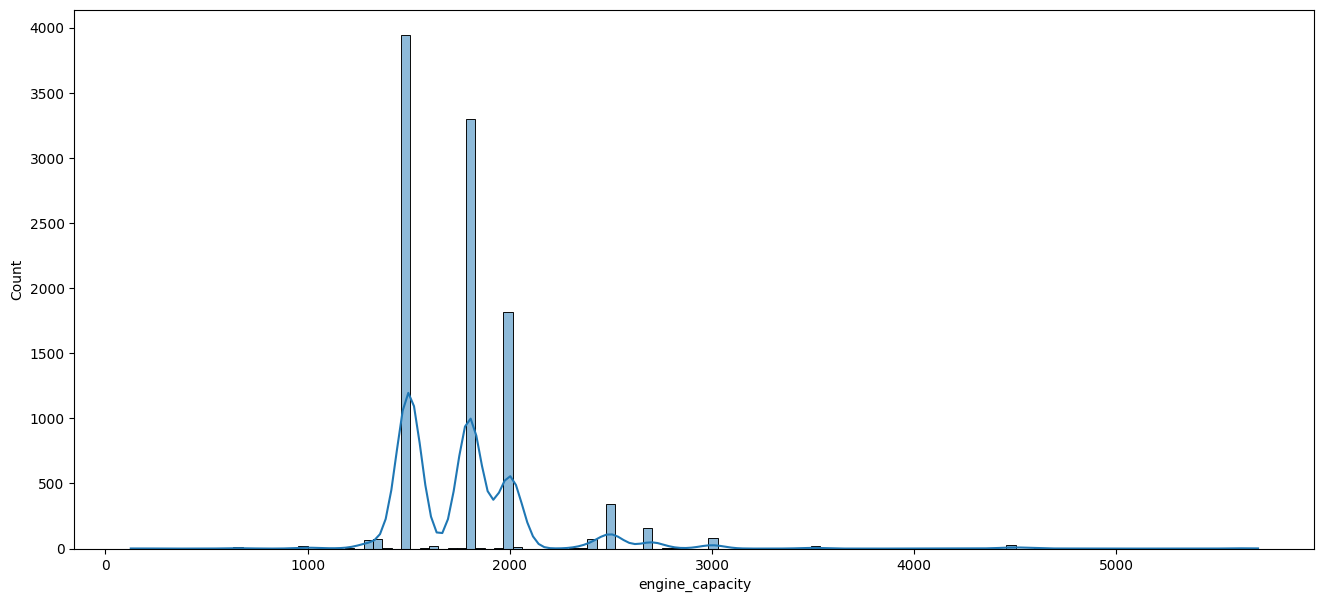

In [59]:
plt.figure(figsize=(16, 7))
sns.histplot(df['engine_capacity'],kde=True)
plt.show()

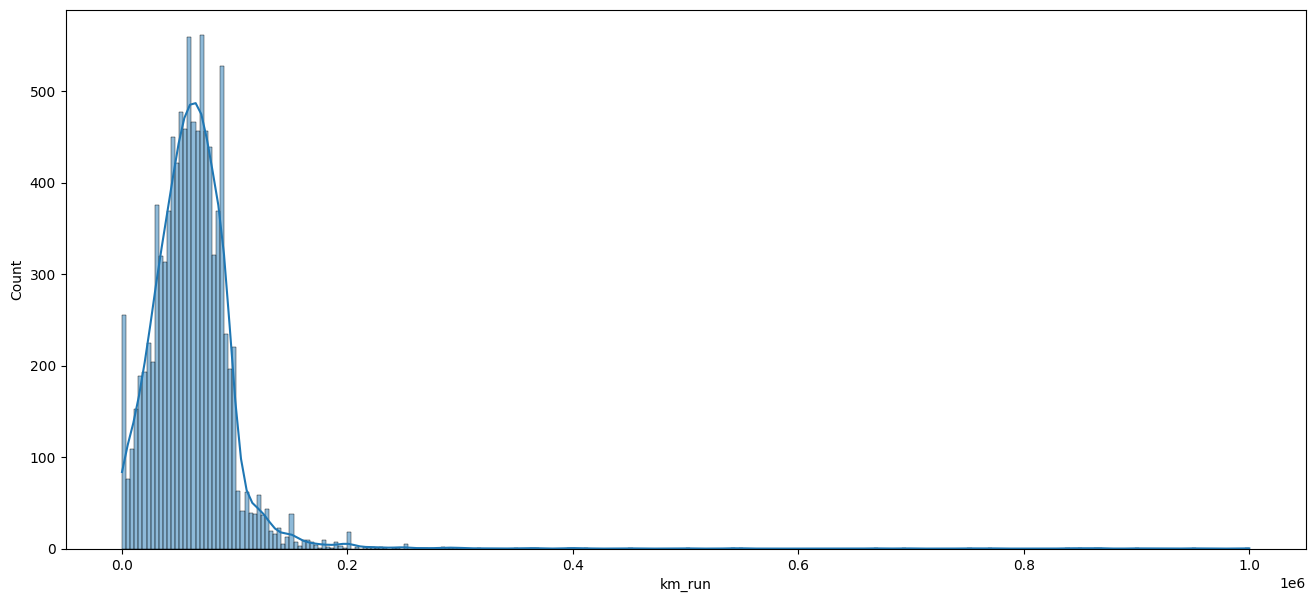

In [60]:
plt.figure(figsize=(16, 7))
sns.histplot(df['km_run'],kde=True)
plt.show()

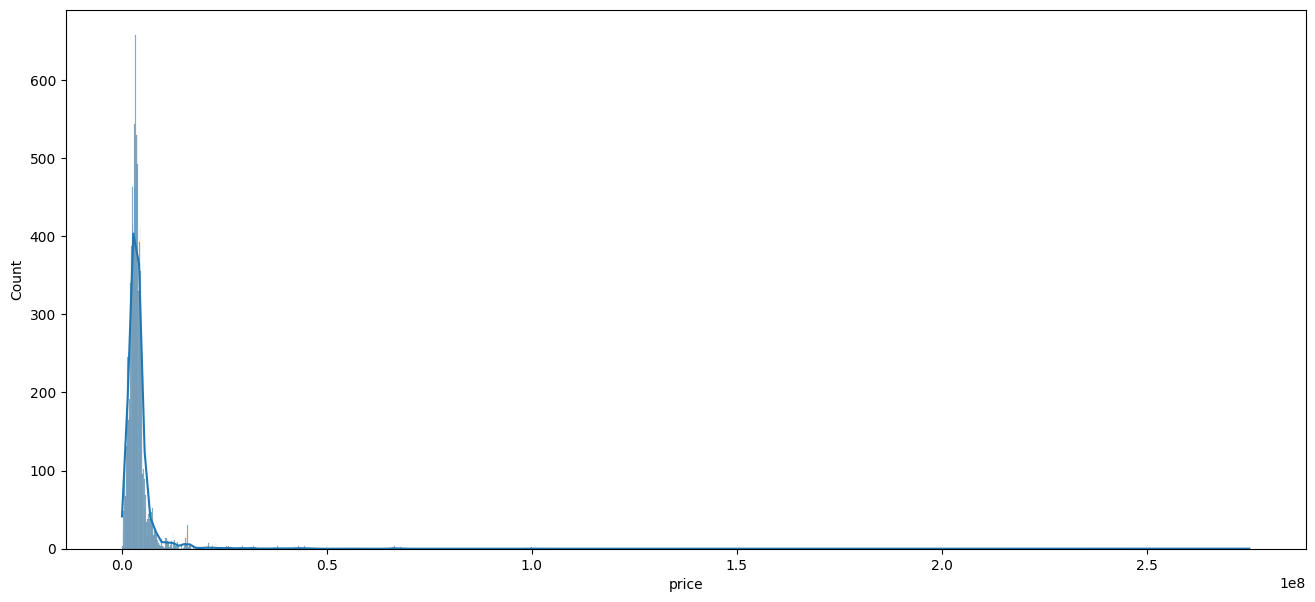

In [61]:
plt.figure(figsize=(16, 7))
sns.histplot(df['price'],kde=True)
plt.show()

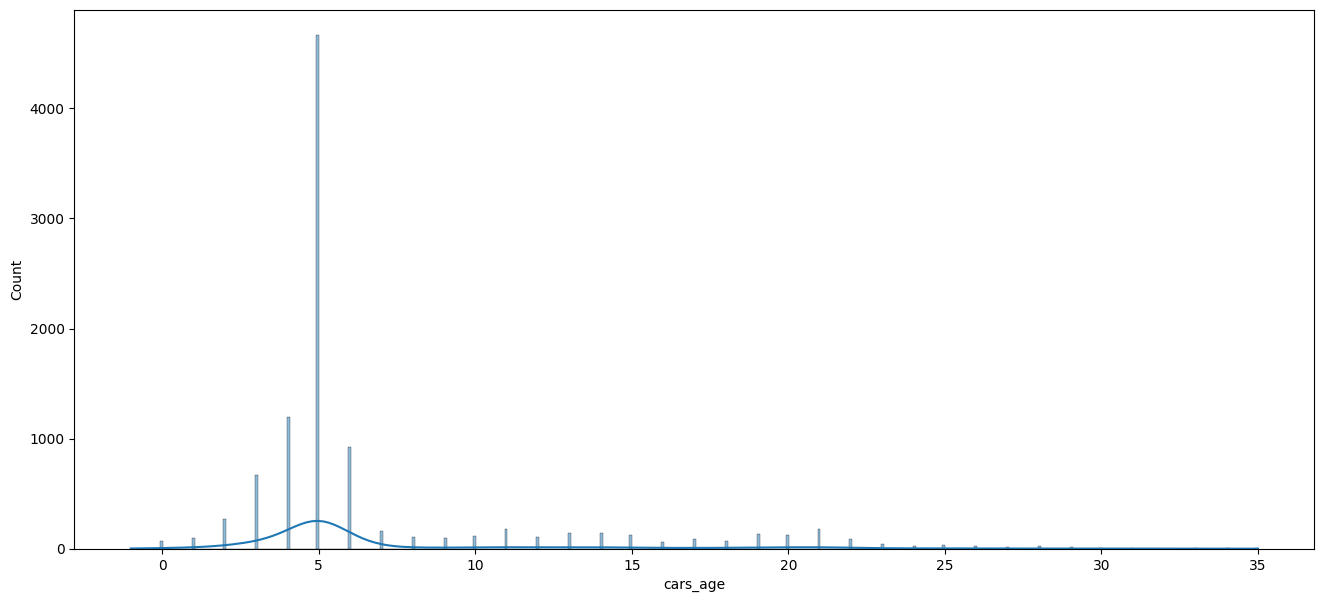

In [62]:
plt.figure(figsize=(16, 7))
sns.histplot(df['cars_age'],kde=True)
plt.show()

In [63]:
df['price_in_million_bt']=df['price']/1000000
df

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age,price_in_million_bt
0,Dhaka,Saloon,Toyota,Used,2000,"CNG, Octane",116000,Noah,2100000,Individual,Uttara,Automatic,14,2.10
1,Dhaka,MPV,Toyota,New,1800,"Petrol, Hybrid, Octane",35200,Noah,4350000,Company,Baridhara,Automatic,3,4.35
2,Dhaka,SUV,Other,Used,1500,"Petrol, Octane",20000,Other,3300000,Individual,Gulshan,Automatic,5,3.30
3,Dhaka,MPV,Toyota,Used,2000,"CNG, Octane",66000,Noah,2050000,Individual,Dhanmondi,Automatic,15,2.05
4,Dhaka,Saloon,Toyota,Used,1500,Other,88000,Other,710000,Company,Mirpur,Automatic,21,0.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,Khulna,Saloon,Toyota,Reconditioned,1500,"Petrol, Octane",59000,Premio,5050000,Company,Khulna Sadar,Automatic,4,5.05
10015,Khulna,Hatchback,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",14670,Aqua,2050000,Company,Khulna Sadar,Automatic,5,2.05
10016,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",65055,Sienta,2950000,Company,Khulna Sadar,Automatic,4,2.95
10017,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Octane",171543,Sienta,2600000,Company,Khulna Sadar,Automatic,6,2.60


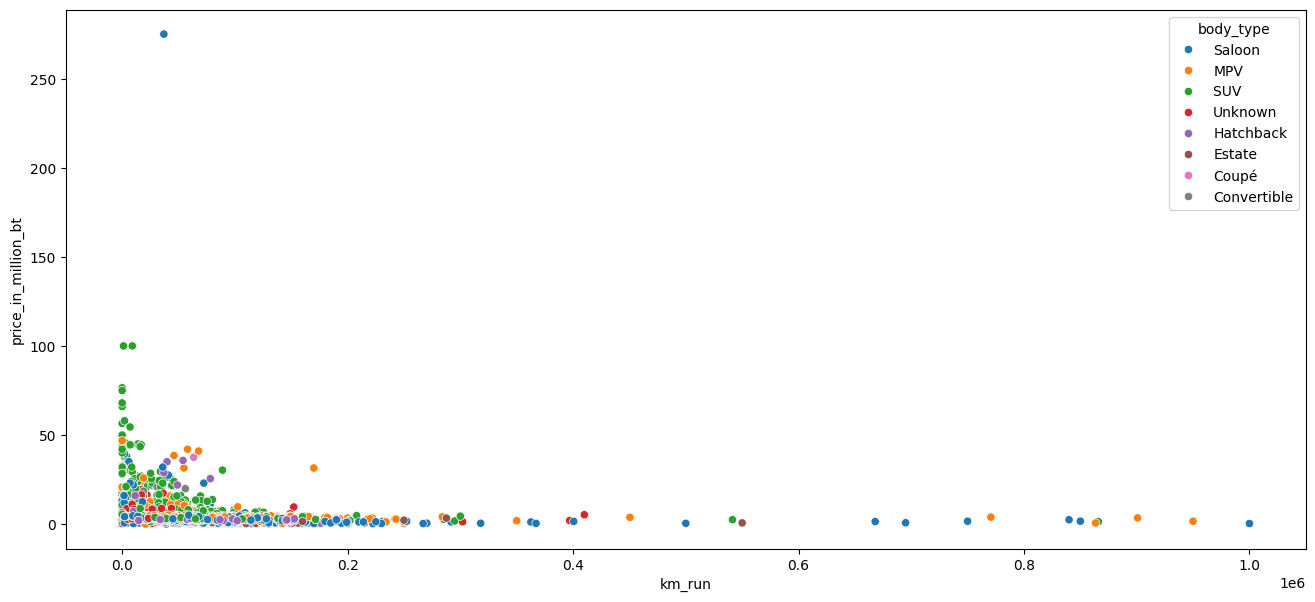

In [64]:
plt.figure(figsize=(16, 7))
sns.scatterplot(data=df,x='km_run',y='price_in_million_bt',hue='body_type')
plt.show()

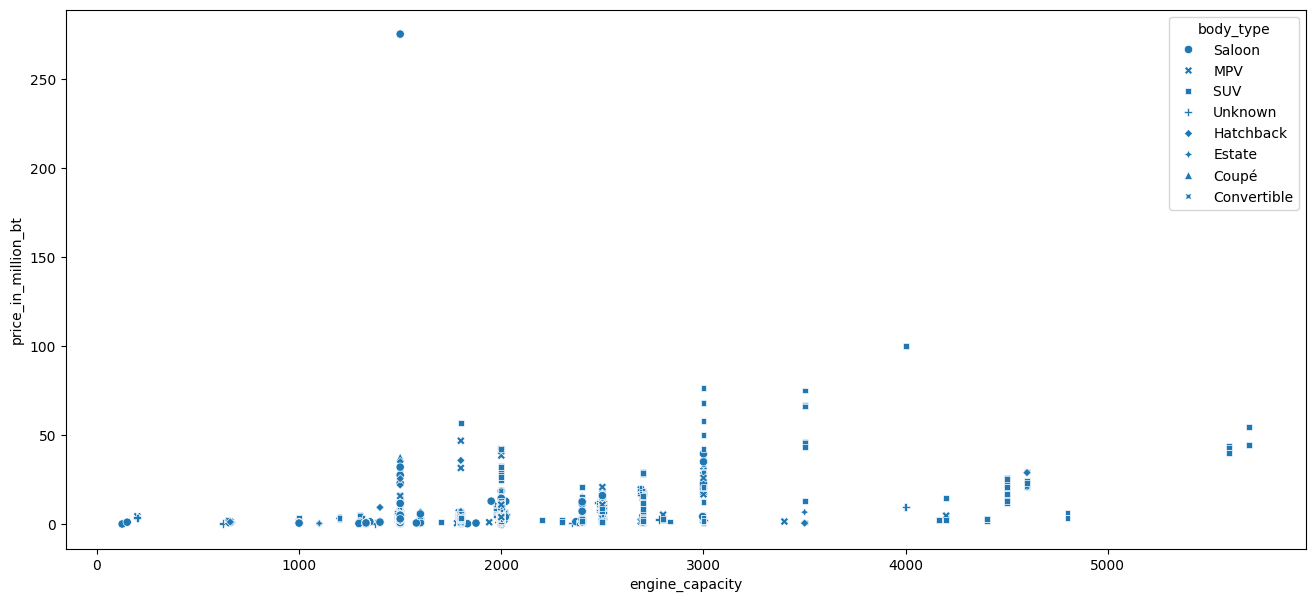

In [65]:
plt.figure(figsize=(16, 7))
sns.scatterplot(data=df,x='engine_capacity',y='price_in_million_bt',style='body_type')
plt.show()

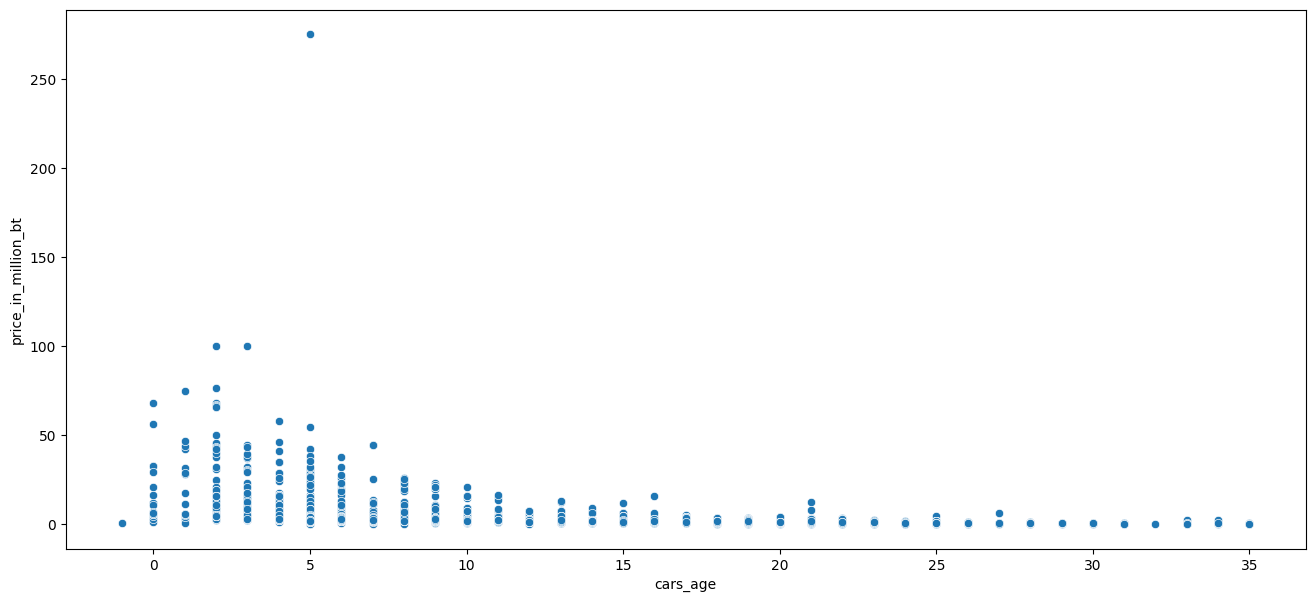

In [66]:
plt.figure(figsize=(16, 7))
sns.scatterplot(data=df,x='cars_age',y='price_in_million_bt')
plt.show()

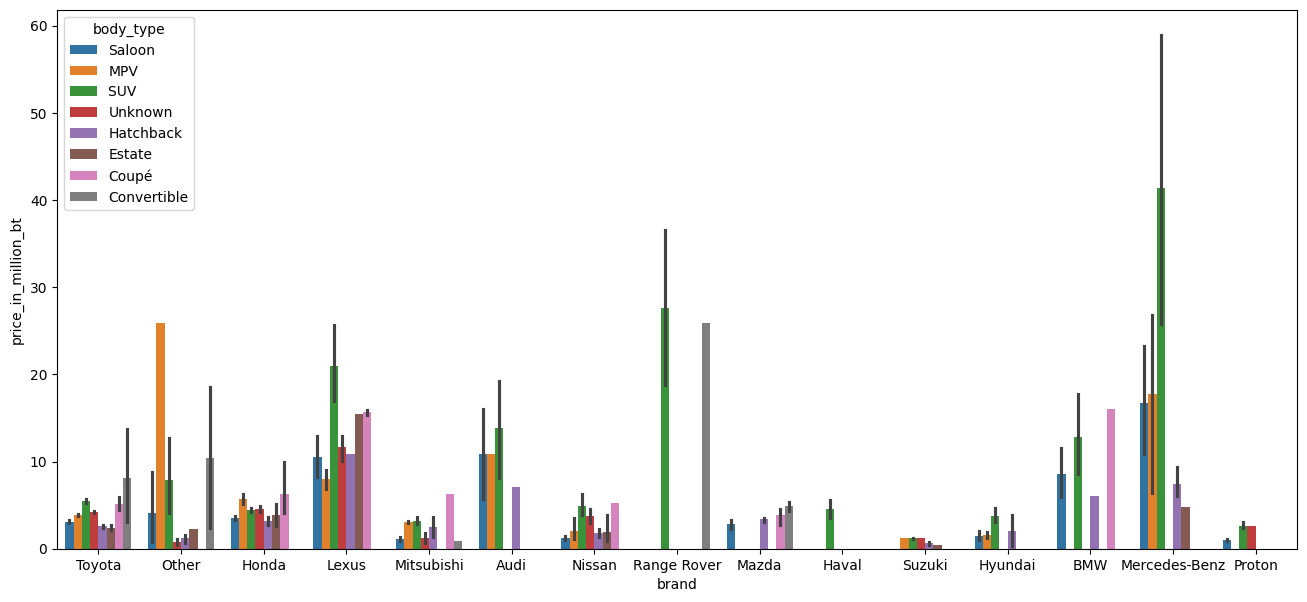

In [67]:
plt.figure(figsize=(16, 7))
sns.barplot(data=df,x='brand',y='price_in_million_bt', hue='body_type')
plt.show()

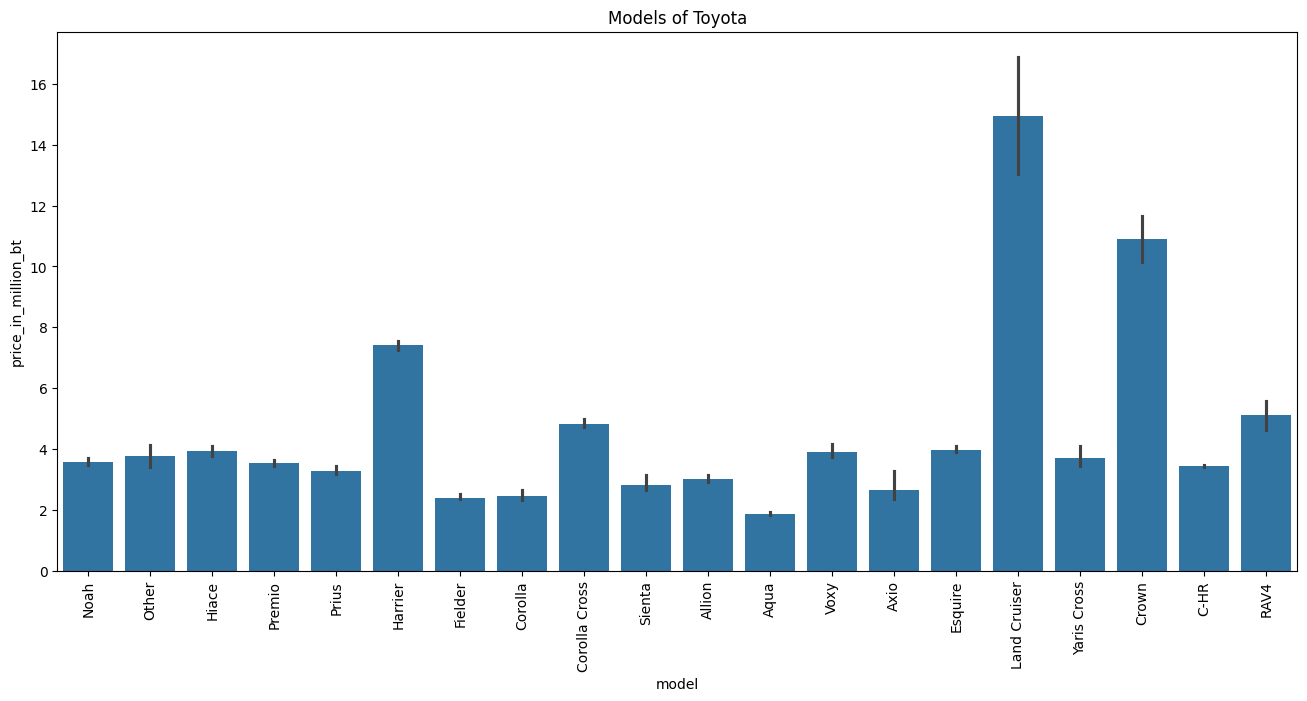

In [68]:
mask = df[df['brand'] == 'Toyota']
plt.figure(figsize=(16, 7))
plt.title('Models of Toyota')
ax = sns.barplot(
    data=mask,
    x='model',
    y='price_in_million_bt',

)
ax.tick_params(axis='x', labelrotation=90)
plt.show()

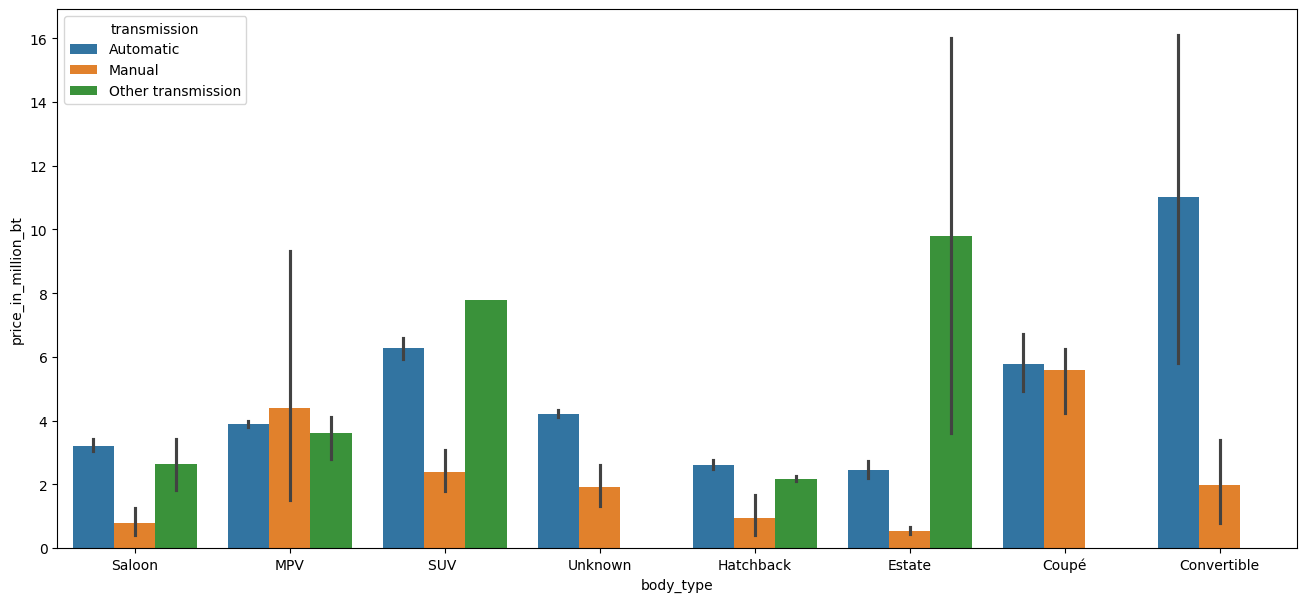

In [69]:
plt.figure(figsize=(16, 7))
sns.barplot(data=df,x='body_type',y='price_in_million_bt', hue='transmission')
plt.show()

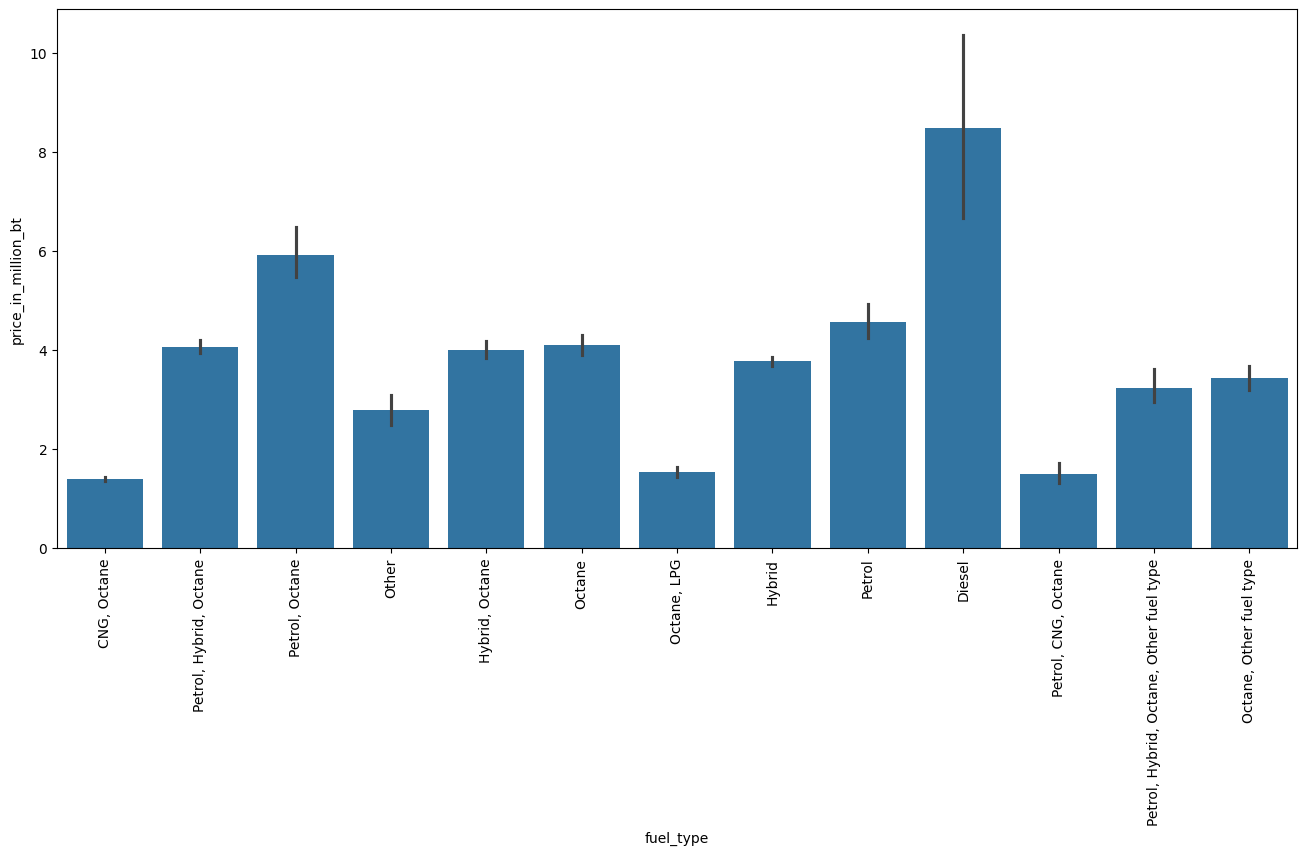

In [70]:
plt.figure(figsize=(16, 7))
ax = sns.barplot(data=df,x='fuel_type',y='price_in_million_bt',estimator='mean')
ax.tick_params(axis='x', labelrotation=90)
plt.show()

# Outliers Detection & Removal

<Axes: ylabel='price'>

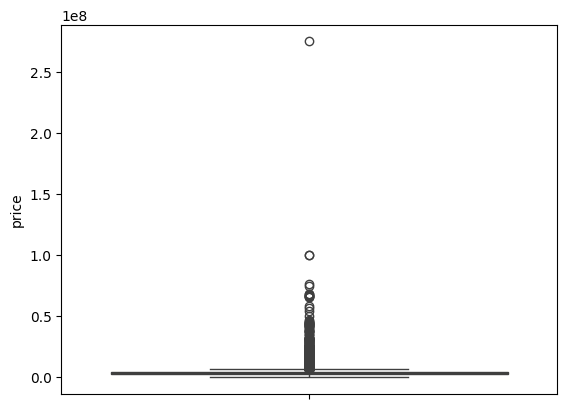

In [71]:
sns.boxplot(df['price'])

<Axes: ylabel='cars_age'>

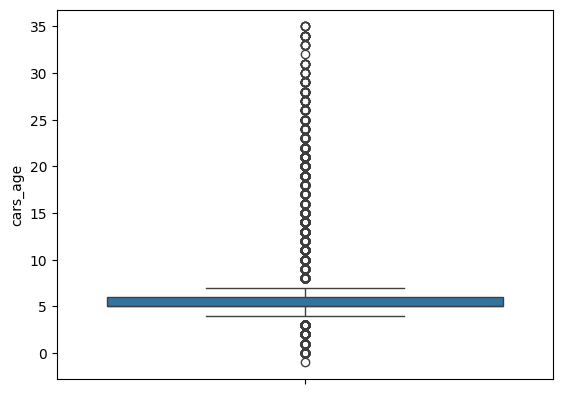

In [72]:
sns.boxplot(df['cars_age'])

<Axes: ylabel='engine_capacity'>

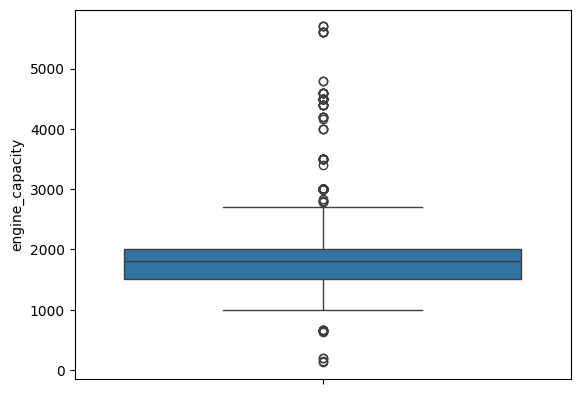

In [73]:
sns.boxplot(df['engine_capacity'])

<Axes: ylabel='km_run'>

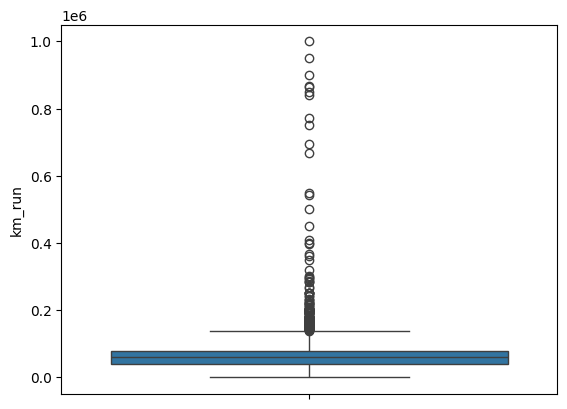

In [74]:
sns.boxplot(df['km_run'])

In [75]:
df

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age,price_in_million_bt
0,Dhaka,Saloon,Toyota,Used,2000,"CNG, Octane",116000,Noah,2100000,Individual,Uttara,Automatic,14,2.10
1,Dhaka,MPV,Toyota,New,1800,"Petrol, Hybrid, Octane",35200,Noah,4350000,Company,Baridhara,Automatic,3,4.35
2,Dhaka,SUV,Other,Used,1500,"Petrol, Octane",20000,Other,3300000,Individual,Gulshan,Automatic,5,3.30
3,Dhaka,MPV,Toyota,Used,2000,"CNG, Octane",66000,Noah,2050000,Individual,Dhanmondi,Automatic,15,2.05
4,Dhaka,Saloon,Toyota,Used,1500,Other,88000,Other,710000,Company,Mirpur,Automatic,21,0.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,Khulna,Saloon,Toyota,Reconditioned,1500,"Petrol, Octane",59000,Premio,5050000,Company,Khulna Sadar,Automatic,4,5.05
10015,Khulna,Hatchback,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",14670,Aqua,2050000,Company,Khulna Sadar,Automatic,5,2.05
10016,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",65055,Sienta,2950000,Company,Khulna Sadar,Automatic,4,2.95
10017,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Octane",171543,Sienta,2600000,Company,Khulna Sadar,Automatic,6,2.60


In [76]:
print(df['engine_capacity'].skew(),
df['km_run'].skew(),df['price'].skew(),df['cars_age'].skew())

3.2627828525081926 7.944635541674919 19.840165840732876 2.2006980397791467


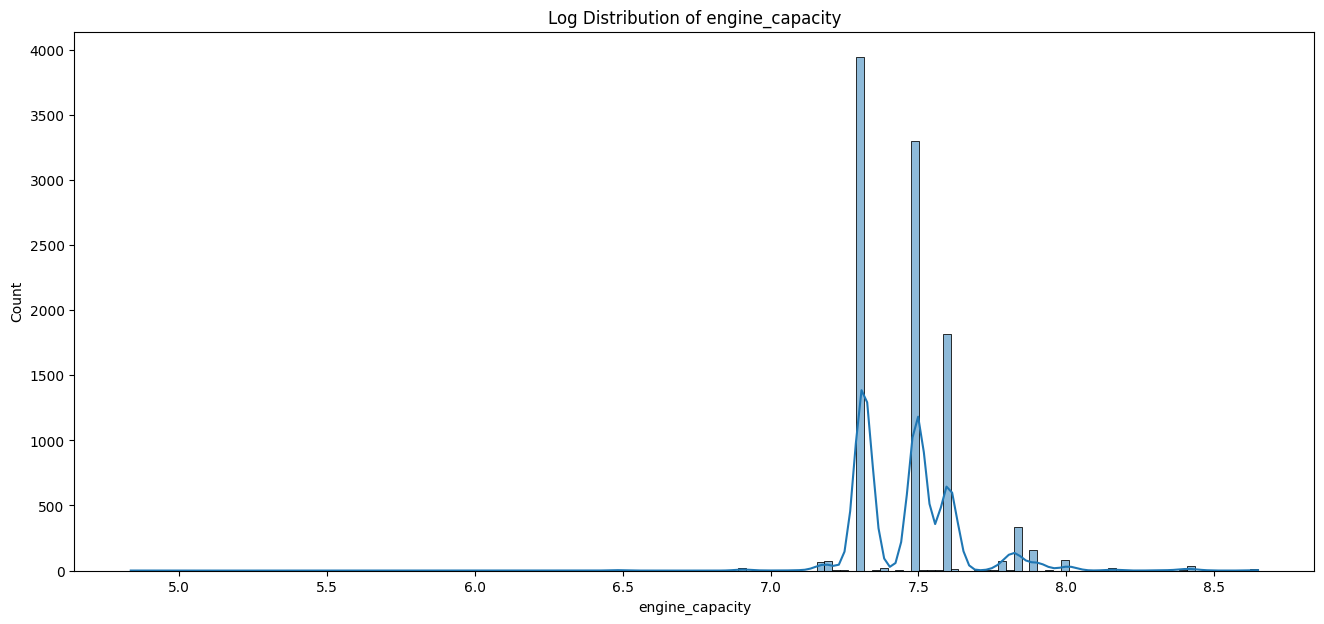

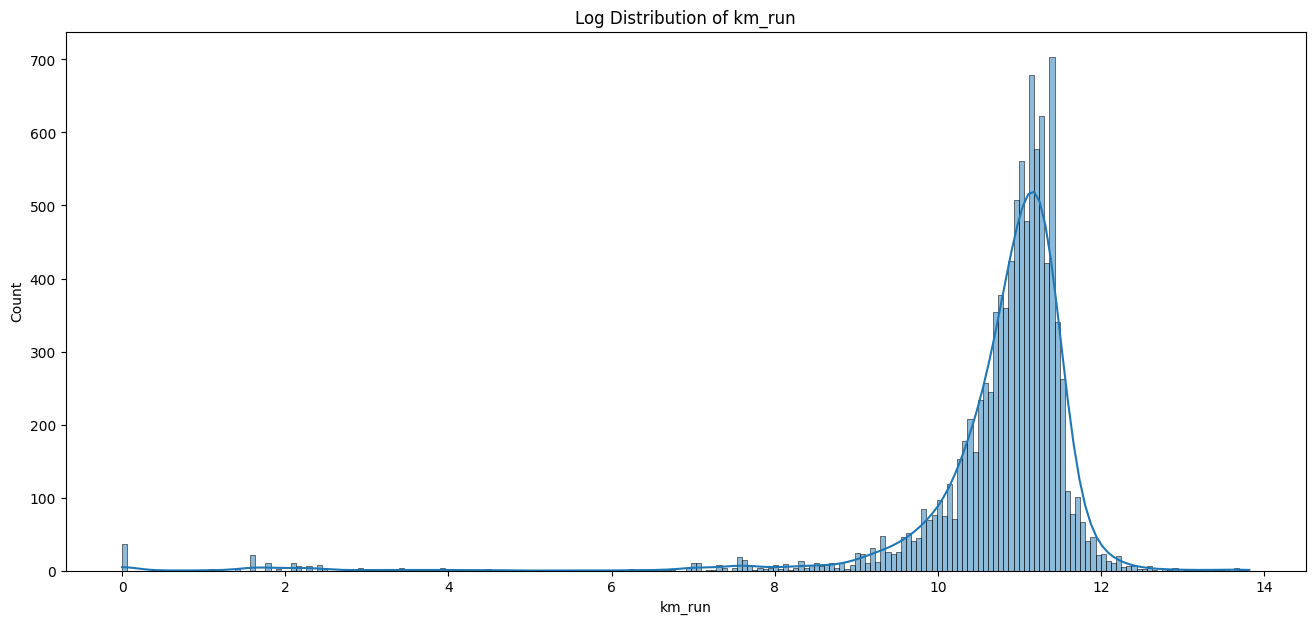

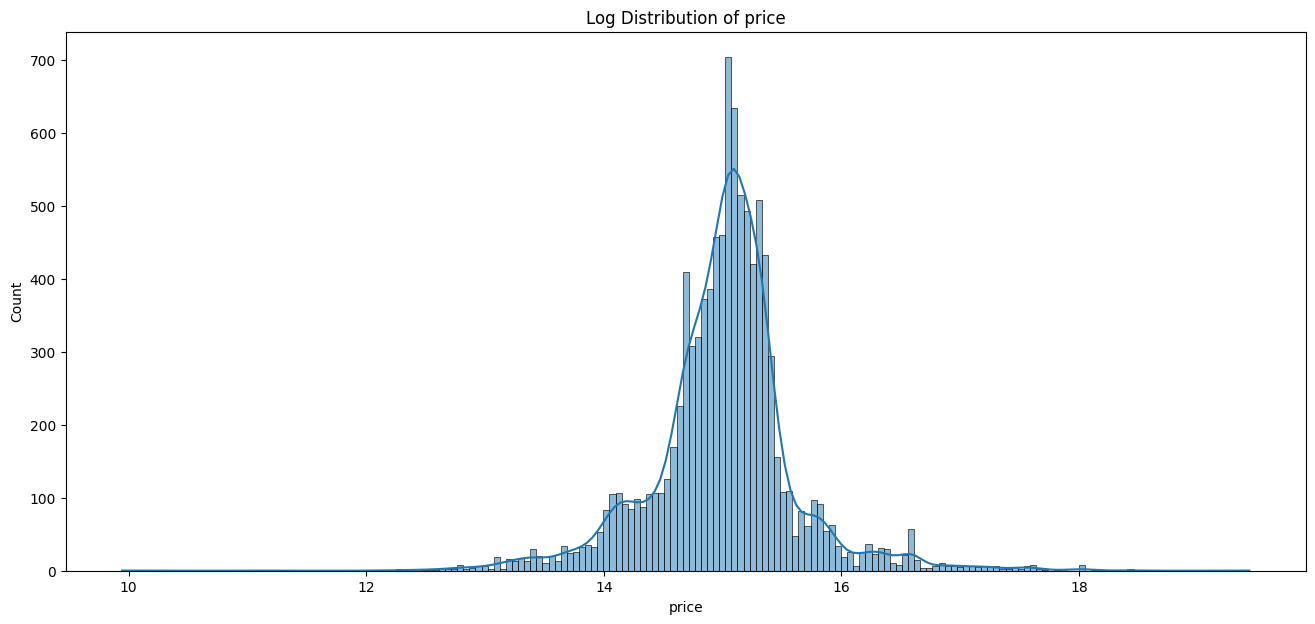

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


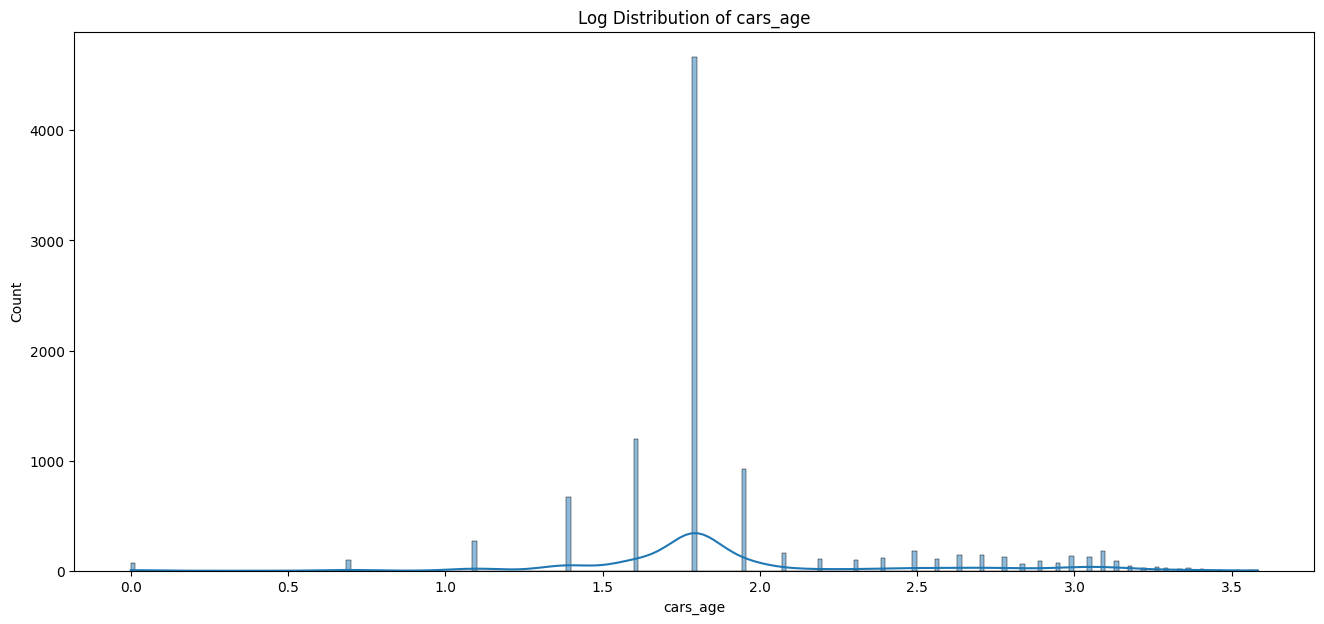

In [77]:
for col in ['engine_capacity', 'km_run', 'price', 'cars_age']:
    plt.figure(figsize=(16, 7))
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f'Log Distribution of {col}')
    plt.show()

In [78]:
def find_outliers(df,column):
    percentile25 = df[column].quantile(0.25)
    percentile75 = df[column].quantile(0.75)
    iqr = percentile75-percentile25
    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr
    mask=(df[column] > upper_limit) | (df[column] < lower_limit)
    return df[mask]

In [79]:
price_outliers=find_outliers(df,'price_in_million_bt')
price_outliers

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age,price_in_million_bt
8,Dhaka,SUV,Toyota,Reconditioned,2000,"Petrol, Octane",40000,Harrier,7800000,Company,Baridhara,Automatic,5,7.80
17,Dhaka,Coupé,Lexus,Reconditioned,2500,"Petrol, Hybrid, Octane",1950,Other,16000000,Company,Baridhara,Automatic,2,16.00
25,Dhaka,Saloon,Audi,Used,2000,Octane,4700,Other,8300000,Individual,Other,Automatic,8,8.30
53,Dhaka,SUV,Range Rover,New,3000,"Petrol, Octane",0,Other,76500000,Company,Banani,Automatic,2,76.50
60,Dhaka,SUV,Other,Used,2000,"Petrol, Octane",18000,Other,25000000,Company,Gulshan,Automatic,2,25.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9930,Dhaka,MPV,Other,Used,3000,Octane,19000,Other,25900000,Company,Baridhara,Automatic,4,25.90
9970,Dhaka,Saloon,Toyota,Reconditioned,2400,"Petrol, Hybrid, Octane",18013,Crown,12500000,Company,Baridhara,Automatic,3,12.50
9971,Dhaka,Saloon,Toyota,Reconditioned,2500,"Petrol, Hybrid, Octane",1650,Crown,16000000,Company,Baridhara,Automatic,2,16.00
9981,Khulna,SUV,Toyota,Reconditioned,2500,"Petrol, Hybrid, Octane",72000,Harrier,7500000,Company,Khulna Sadar,Automatic,4,7.50


In [80]:
outliers=find_outliers(df,'cars_age')
outliers

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age,price_in_million_bt
0,Dhaka,Saloon,Toyota,Used,2000,"CNG, Octane",116000,Noah,2100000,Individual,Uttara,Automatic,14,2.10
1,Dhaka,MPV,Toyota,New,1800,"Petrol, Hybrid, Octane",35200,Noah,4350000,Company,Baridhara,Automatic,3,4.35
3,Dhaka,MPV,Toyota,Used,2000,"CNG, Octane",66000,Noah,2050000,Individual,Dhanmondi,Automatic,15,2.05
4,Dhaka,Saloon,Toyota,Used,1500,Other,88000,Other,710000,Company,Mirpur,Automatic,21,0.71
10,Dhaka,Saloon,Toyota,Used,1500,Other,61530,Corolla,1330000,Individual,Mirpur,Automatic,19,1.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9970,Dhaka,Saloon,Toyota,Reconditioned,2400,"Petrol, Hybrid, Octane",18013,Crown,12500000,Company,Baridhara,Automatic,3,12.50
9971,Dhaka,Saloon,Toyota,Reconditioned,2500,"Petrol, Hybrid, Octane",1650,Crown,16000000,Company,Baridhara,Automatic,2,16.00
9978,Khulna,SUV,Toyota,Reconditioned,1800,"Petrol, Hybrid, Octane",4,Corolla Cross,5550000,Company,Khulna Sadar,Automatic,1,5.55
9988,Khulna,SUV,Toyota,Reconditioned,2500,"Petrol, Hybrid, Octane",16000,Harrier,8750000,Company,Khulna Sadar,Automatic,3,8.75


In [81]:
outliers=find_outliers(df,'km_run')
outliers

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age,price_in_million_bt
34,Dhaka,Saloon,Toyota,Used,1500,Other,150000,Premio,2000000,Individual,Basundhara,Automatic,17,2.00
79,Dhaka Division,Saloon,Nissan,Used,1500,Other,291856,Other,1200000,Individual,Other,Automatic,17,1.20
81,Dhaka,Hatchback,Toyota,Used,1500,"Hybrid, Octane",167000,Aqua,1300000,Individual,Mirpur,Automatic,11,1.30
84,Other,Unknown,Toyota,Used,1500,Other,200000,Corolla,1150000,Individual,Other,Automatic,23,1.15
94,Dhaka,Saloon,Toyota,Used,1500,"CNG, Octane",190000,Allion,1470000,Individual,Rampura,Automatic,20,1.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9849,Dhaka,Saloon,Toyota,Reconditioned,1500,Hybrid,190000,Axio,2400000,Company,Mirpur,Automatic,5,2.40
9987,Khulna,Hatchback,Toyota,Reconditioned,1500,"Petrol, Octane",171501,Sienta,2600000,Company,Khulna Sadar,Automatic,6,2.60
10007,Khulna,Hatchback,Toyota,Reconditioned,1500,"Petrol, Octane",152743,Axio,2990000,Company,Khulna Sadar,Automatic,5,2.99
10011,Khulna,Hatchback,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",146000,Fielder,2340000,Company,Khulna Sadar,Automatic,5,2.34


In [82]:
outliers=find_outliers(df,'engine_capacity')
outliers

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age,price_in_million_bt
53,Dhaka,SUV,Range Rover,New,3000,"Petrol, Octane",0,Other,76500000,Company,Banani,Automatic,2,76.500
61,Dhaka,SUV,Lexus,Used,3500,"Petrol, Hybrid, Octane",23414,Other,13000000,Company,Gulshan,Automatic,4,13.000
140,Chattogram,Estate,Nissan,Reconditioned,3500,Octane,47000,Other,6700000,Company,Agrabad,Automatic,5,6.700
160,Dhaka,SUV,Toyota,Used,4500,Diesel,42556,Land Cruiser,26000000,Company,Banani,Automatic,6,26.000
162,Chattogram,MPV,Toyota,Reconditioned,200,Octane,37000,Hiace,4400000,Company,Agrabad,Automatic,4,4.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9585,Dhaka,MPV,Toyota,Used,3400,Octane,123000,Hiace,1450000,Company,Mirpur,Automatic,23,1.450
9784,Dhaka,Hatchback,Toyota,Reconditioned,660,"Petrol, Octane",58000,Other,1200000,Company,Gulshan,Automatic,5,1.200
9822,Dhaka,SUV,Toyota,Used,4500,Diesel,32739,Land Cruiser,16700000,Company,Banani,Automatic,11,16.700
9863,Dhaka,SUV,Mitsubishi,Used,3000,Octane,70700,Other,1945000,Company,Banani,Automatic,21,1.945


In [83]:
df.shape

(10018, 14)

In [84]:
df = df[~((df['km_run'] > 500_000) & (df['cars_age'] < 2))]
df = df[~((df['km_run'] == 0) & (df['cars_age'] > 1))]

df.reset_index(drop=True, inplace=True)

In [85]:
df.shape

(9999, 14)

In [86]:
df = df.drop(columns=['price_in_million_bt'])
df

,area,body_type,brand,condition,engine_capacity,fuel_type,km_run,model,price,sold_by,subarea,transmission,cars_age
0,Dhaka,Saloon,Toyota,Used,2000,"CNG, Octane",116000,Noah,2100000,Individual,Uttara,Automatic,14
1,Dhaka,MPV,Toyota,New,1800,"Petrol, Hybrid, Octane",35200,Noah,4350000,Company,Baridhara,Automatic,3
2,Dhaka,SUV,Other,Used,1500,"Petrol, Octane",20000,Other,3300000,Individual,Gulshan,Automatic,5
3,Dhaka,MPV,Toyota,Used,2000,"CNG, Octane",66000,Noah,2050000,Individual,Dhanmondi,Automatic,15
4,Dhaka,Saloon,Toyota,Used,1500,Other,88000,Other,710000,Company,Mirpur,Automatic,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,Khulna,Saloon,Toyota,Reconditioned,1500,"Petrol, Octane",59000,Premio,5050000,Company,Khulna Sadar,Automatic,4
9995,Khulna,Hatchback,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",14670,Aqua,2050000,Company,Khulna Sadar,Automatic,5
9996,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Hybrid, Octane",65055,Sienta,2950000,Company,Khulna Sadar,Automatic,4
9997,Khulna,SUV,Toyota,Reconditioned,1500,"Petrol, Octane",171543,Sienta,2600000,Company,Khulna Sadar,Automatic,6


# Train, Validation and Test Split

The dataset was divided into three subsets:

```text
Training set:   70%
Validation set: 15%
Test set:       15%
```

The training set was used to fit the models, the validation set was used for model selection and monitoring during training, and the test set was kept separate for final evaluation.

This separation helps prevent the test set from influencing model development and provides a more reliable estimate of the model's generalization performance.

----------

In [87]:
X = df.drop(columns=['price'])
y = df['price']

In [88]:
X_train, X_temp, y_train,  y_temp = train_test_split(X,y,train_size=0.7,random_state=42)
X_test, X_val, y_test,  y_val = train_test_split(X_temp,y_temp,train_size=0.5,random_state=42)

# Target Engineering

The original `price` variable is used as the regression target.

To create the second task, the price distribution was divided into three tiers using the 33rd and 66th percentiles calculated **only from the training data**.

```text
Price < Q1       → Low
Q1 ≤ Price < Q2  → Medium
Price ≥ Q2       → High
```

The resulting `price_tier` variable provides a classification target corresponding to the original regression target.

----------


In [89]:
q1 = y_train.quantile(1/3)
q2 = y_train.quantile(2/3)
print("q1: ", q1 )
print("q2: ", q2 )

q1:  2850000.0
q2:  3950000.0


In [90]:
def get_price_tier(price):
    if price<= q1:
        return 'Low'
    elif price <= q2:
        return 'Medium'
    else:
        return 'High'

In [91]:
y_train_tier = y_train.apply(get_price_tier)
y_test_tier = y_test.apply(get_price_tier)
y_val_tier = y_val.apply(get_price_tier)

In [92]:
print(y_train_tier.value_counts())
print(y_val_tier.value_counts())
print(y_test_tier.value_counts())

price
Medium    2372
Low       2344
High      2283
Name: count, dtype: int64
price
Low       521
High      513
Medium    466
Name: count, dtype: int64
price
Medium    517
Low       493
High      490
Name: count, dtype: int64


# Preprocessing

In [93]:
num_cols = ['engine_capacity', 'km_run', 'cars_age']

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

In [94]:
cat_cols = ['area','body_type','brand','condition','fuel_type','model','sold_by','subarea','transmission']

ohe = OneHotEncoder(drop='first',sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_val_cat = ohe.transform(X_val[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

In [95]:
X_train_new = np.hstack((X_train_num,X_train_cat))
X_val_new = np.hstack((X_val_num,X_val_cat))
X_test_new = np.hstack((X_test_num,X_test_cat))

In [96]:
X_train_new

array([[ 0.05473017, -0.63366761, -0.55221479, ...,  0.        ,
         0.        ,  0.        ],
       [-0.74214759, -0.20673284, -0.36440434, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.05473017, -0.44391883, -0.55221479, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.05473017, -1.0555266 , -0.55221479, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.05473017,  0.5522623 , -0.36440434, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.05473017, -0.4571538 , -0.55221479, ...,  0.        ,
         0.        ,  0.        ]])

In [97]:
mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

y_train_tier_encoded = y_train_tier.map(mapping)
y_val_tier_encoded = y_val_tier.map(mapping)
y_test_tier_encoded = y_test_tier.map(mapping)

In [98]:
price_scaler = StandardScaler()

y_train_scaled = price_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = price_scaler.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = price_scaler.transform(
    y_test.values.reshape(-1, 1)
)

# Baseline Models

Before building the neural network, several traditional machine learning models were trained to establish baseline performance.

### Regression

-   Linear Regression
    
-   Random Forest Regressor
    
-   Gradient Boosting Regressor
    

### Classification

-   Logistic Regression
    
-   Random Forest Classifier
    
-   Gradient Boosting Classifier
    

The baseline models provide a reference point for evaluating whether the proposed multi-task neural network provides competitive performance.

In [99]:
lr = LinearRegression()
lr.fit(X_train_new, y_train_scaled)
y_pred = lr.predict(X_test_new)
print("MAE",mean_absolute_error(y_test_scaled,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test_scaled,y_pred)))
print("R2 score",r2_score(y_test_scaled,y_pred))

MAE 0.2045318809183094
RMSE 0.5506069847124925
R2 score 0.5824367997533508


In [100]:
rf = RandomForestRegressor(n_estimators=100, max_depth=5)
rf.fit(X_train_new, y_train_scaled.ravel())
y_pred = rf.predict(X_test_new)
print("MAE",mean_absolute_error(y_test_scaled,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test_scaled,y_pred)))
print("R2 score",r2_score(y_test_scaled,y_pred))

MAE 0.17275357623905147
RMSE 0.38486842615871836
R2 score 0.7959844114430944


In [101]:
gb = GradientBoostingRegressor()
gb.fit(X_train_new, y_train_scaled.ravel())
y_pred = gb.predict(X_test_new)
print("MAE",mean_absolute_error(y_test_scaled,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test_scaled,y_pred)))
print("R2 score",r2_score(y_test_scaled,y_pred))

MAE 0.13292707994298825
RMSE 0.315726663055561
R2 score 0.8627029190717627


In [102]:
lr = LogisticRegression()
lr.fit(X_train_new, y_train_tier_encoded)
y_pred = lr.predict(X_test_new)
print("Accuracy",accuracy_score(y_test_tier_encoded,y_pred))
print("F1 Score",f1_score(y_test_tier_encoded,y_pred,average='macro'))
print("Confusion matrix\n",confusion_matrix(y_test_tier_encoded,y_pred))
print("Classification Report\n",classification_report(y_test_tier_encoded,y_pred))

Accuracy 0.8546666666666667
F1 Score 0.8548939482380219
Confusion matrix
 [[466  23   4]
 [ 46 409  62]
 [  4  79 407]]
Classification Report
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       493
           1       0.80      0.79      0.80       517
           2       0.86      0.83      0.85       490

    accuracy                           0.85      1500
   macro avg       0.85      0.86      0.85      1500
weighted avg       0.85      0.85      0.85      1500



In [103]:
rf = RandomForestClassifier()
rf.fit(X_train_new, y_train_tier_encoded)
y_pred = rf.predict(X_test_new)
print("Accuracy",accuracy_score(y_test_tier_encoded,y_pred))
print("F1 Score",f1_score(y_test_tier_encoded,y_pred,average='macro'))
print("Confusion matrix\n",confusion_matrix(y_test_tier_encoded,y_pred))

Accuracy 0.8906666666666667
F1 Score 0.8910181436400038
Confusion matrix
 [[464  27   2]
 [ 36 429  52]
 [  3  44 443]]


In [104]:
gb = GradientBoostingClassifier(n_estimators=300)
gb.fit(X_train_new, y_train_tier_encoded)
y_pred = gb.predict(X_test_new)
print("Accuracy",accuracy_score(y_test_tier_encoded,y_pred))
print("F1 Score",f1_score(y_test_tier_encoded,y_pred,average='macro'))
print("Confusion matrix\n",confusion_matrix(y_test_tier_encoded,y_pred))

Accuracy 0.8973333333333333
F1 Score 0.8977042168929831
Confusion matrix
 [[466  24   3]
 [ 39 436  42]
 [  2  44 444]]


# Multi-Input Architecture

The deep learning model uses the **Keras Functional API** because the project requires multiple independent inputs and multiple outputs.

The model receives:

```text
Numerical features
        ↓
   Dense branch

Categorical features
        ↓
 StringLookup
        ↓
   Embedding
        ↓
     Dense
```

The numerical and categorical representations are then concatenated and passed through shared Dense layers.

The shared representation is used to generate two outputs:

```text
                    Shared Representation
                            │
                 ┌──────────┴──────────┐
                 ↓                     ↓
          Price Regression       Price Classification
             Dense(1)                Dense(3)
             Linear                 Softmax
```

This architecture allows the model to learn shared information between the two related prediction tasks.


In [105]:
transfromer = ColumnTransformer(transformers=[('scaler',StandardScaler(),num_cols)],remainder='passthrough')

In [106]:
X_train_scaled = transfromer.fit_transform(X_train)
X_val_scaled = transfromer.transform(X_val)
X_test_scaled = transfromer.transform(X_test)

In [107]:
X_train_scaled.shape

(6999, 12)

# Categorical Embeddings

Instead of one-hot encoding the categorical variables, each categorical feature is converted into an integer representation using `StringLookup`.

The integer representation is then passed through an `Embedding` layer.

For an embedding dimension of 8, each category is represented by an 8-dimensional trainable vector.

For example:

```text
Toyota
   ↓
Integer ID
   ↓
Embedding
   ↓
[0.21, -0.14, 0.63, ..., 0.08]
```

Each categorical column has its own embedding space.

The resulting embeddings are flattened and concatenated to form a unified categorical representation before being combined with the numerical branch.

In [108]:
lookups = {}

for col in cat_cols:
    lookup = StringLookup(
        output_mode='int',
        num_oov_indices=1
    )
    
    lookup.adapt(X_train[col].astype(str))
    lookups[col] = lookup

I0000 00:00:1786910500.246836      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786910500.249754      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [109]:
categorical_inputs = []
categorical_embeddings = []

for col in cat_cols:

    # Input
    inp = Input(
        shape=(1,),
        dtype=tf.string,
        name=col
    )

    # String → integer ID
    encoded = lookups[col](inp)

    # Integer ID → embedding vector
    embedding = Embedding(
        input_dim=lookups[col].vocabulary_size(),
        output_dim=8,
        name=f'{col}_embedding'
    )(encoded)

    # Remove the extra dimension
    embedding = Flatten()(embedding)

    categorical_inputs.append(inp)
    categorical_embeddings.append(embedding)

In [110]:
categorical_branch = Concatenate(
    name='categorical_concat'
)(categorical_embeddings)

categorical_branch = Dense(
    64,
    activation='relu'
)(categorical_branch)

In [111]:
numeric_input = Input(
    shape=(X_train_num.shape[1],),
    name='numerical_input'
)

numeric_branch = Dense(
    32,
    activation='relu'
)(numeric_input)

# Multi-Output Architecture

The model produces two outputs:

### Price Output

```python
Dense(1, activation='linear')
```

This output predicts the continuous car price and is treated as a regression task.

### Tier Output

```python
Dense(3, activation='softmax')
```

This output predicts the probability of the car belonging to each of the three price tiers.

The class with the highest probability is selected as the predicted tier.


In [112]:
combined = Concatenate()([
    numeric_branch,
    categorical_branch
])

combined = Dense(64, activation='relu')(combined)
combined = Dense(32, activation='relu')(combined)

In [113]:
price_output = Dense(1, activation='linear', name='price')(combined)
tier_output = Dense(3, activation='softmax', name='tier')(combined)

In [114]:
model = Model(inputs=[numeric_input] + categorical_inputs,outputs=[price_output,tier_output])

In [115]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ area (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body_type           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ brand (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ condition           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuel_type           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sold_by             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subarea             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transmission        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup       │ (None, 1)         │          0 │ area[0][0]        │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_1     │ (None, 1)         │          0 │ body_type[0][0]   │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_2     │ (None, 1)         │          0 │ brand[0][0]       │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_3     │ (None, 1)         │          0 │ condition[0][0]   │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_4     │ (None, 1)         │          0 │ fuel_type[0][0]   │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_5     │ (None, 1)         │          0 │ model[0][0]       │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_6     │ (None, 1)         │          0 │ sold_by[0][0]     │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_7     │ (None, 1)         │          0 │ subarea[0][0]     │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_8     │ (None, 1)         │          0 │ transmission[0][

 Total params: 14,052 (54.89 KB)

 Trainable params: 14,052 (54.89 KB)

 Non-trainable params: 0 (0.00 B)

# Model Architecture Visualization

The final model architecture was visualized using `plot_model()`.

The architecture diagram demonstrates the key components of the proposed model:

-   Multiple numerical/categorical inputs
    
-   Categorical embedding branches
    
-   Feature concatenation
    
-   Shared Dense layers
    
-   Separate regression and classification output heads
    

This visualization provides a clear representation of the multi-input, multi-output Functional API architecture.

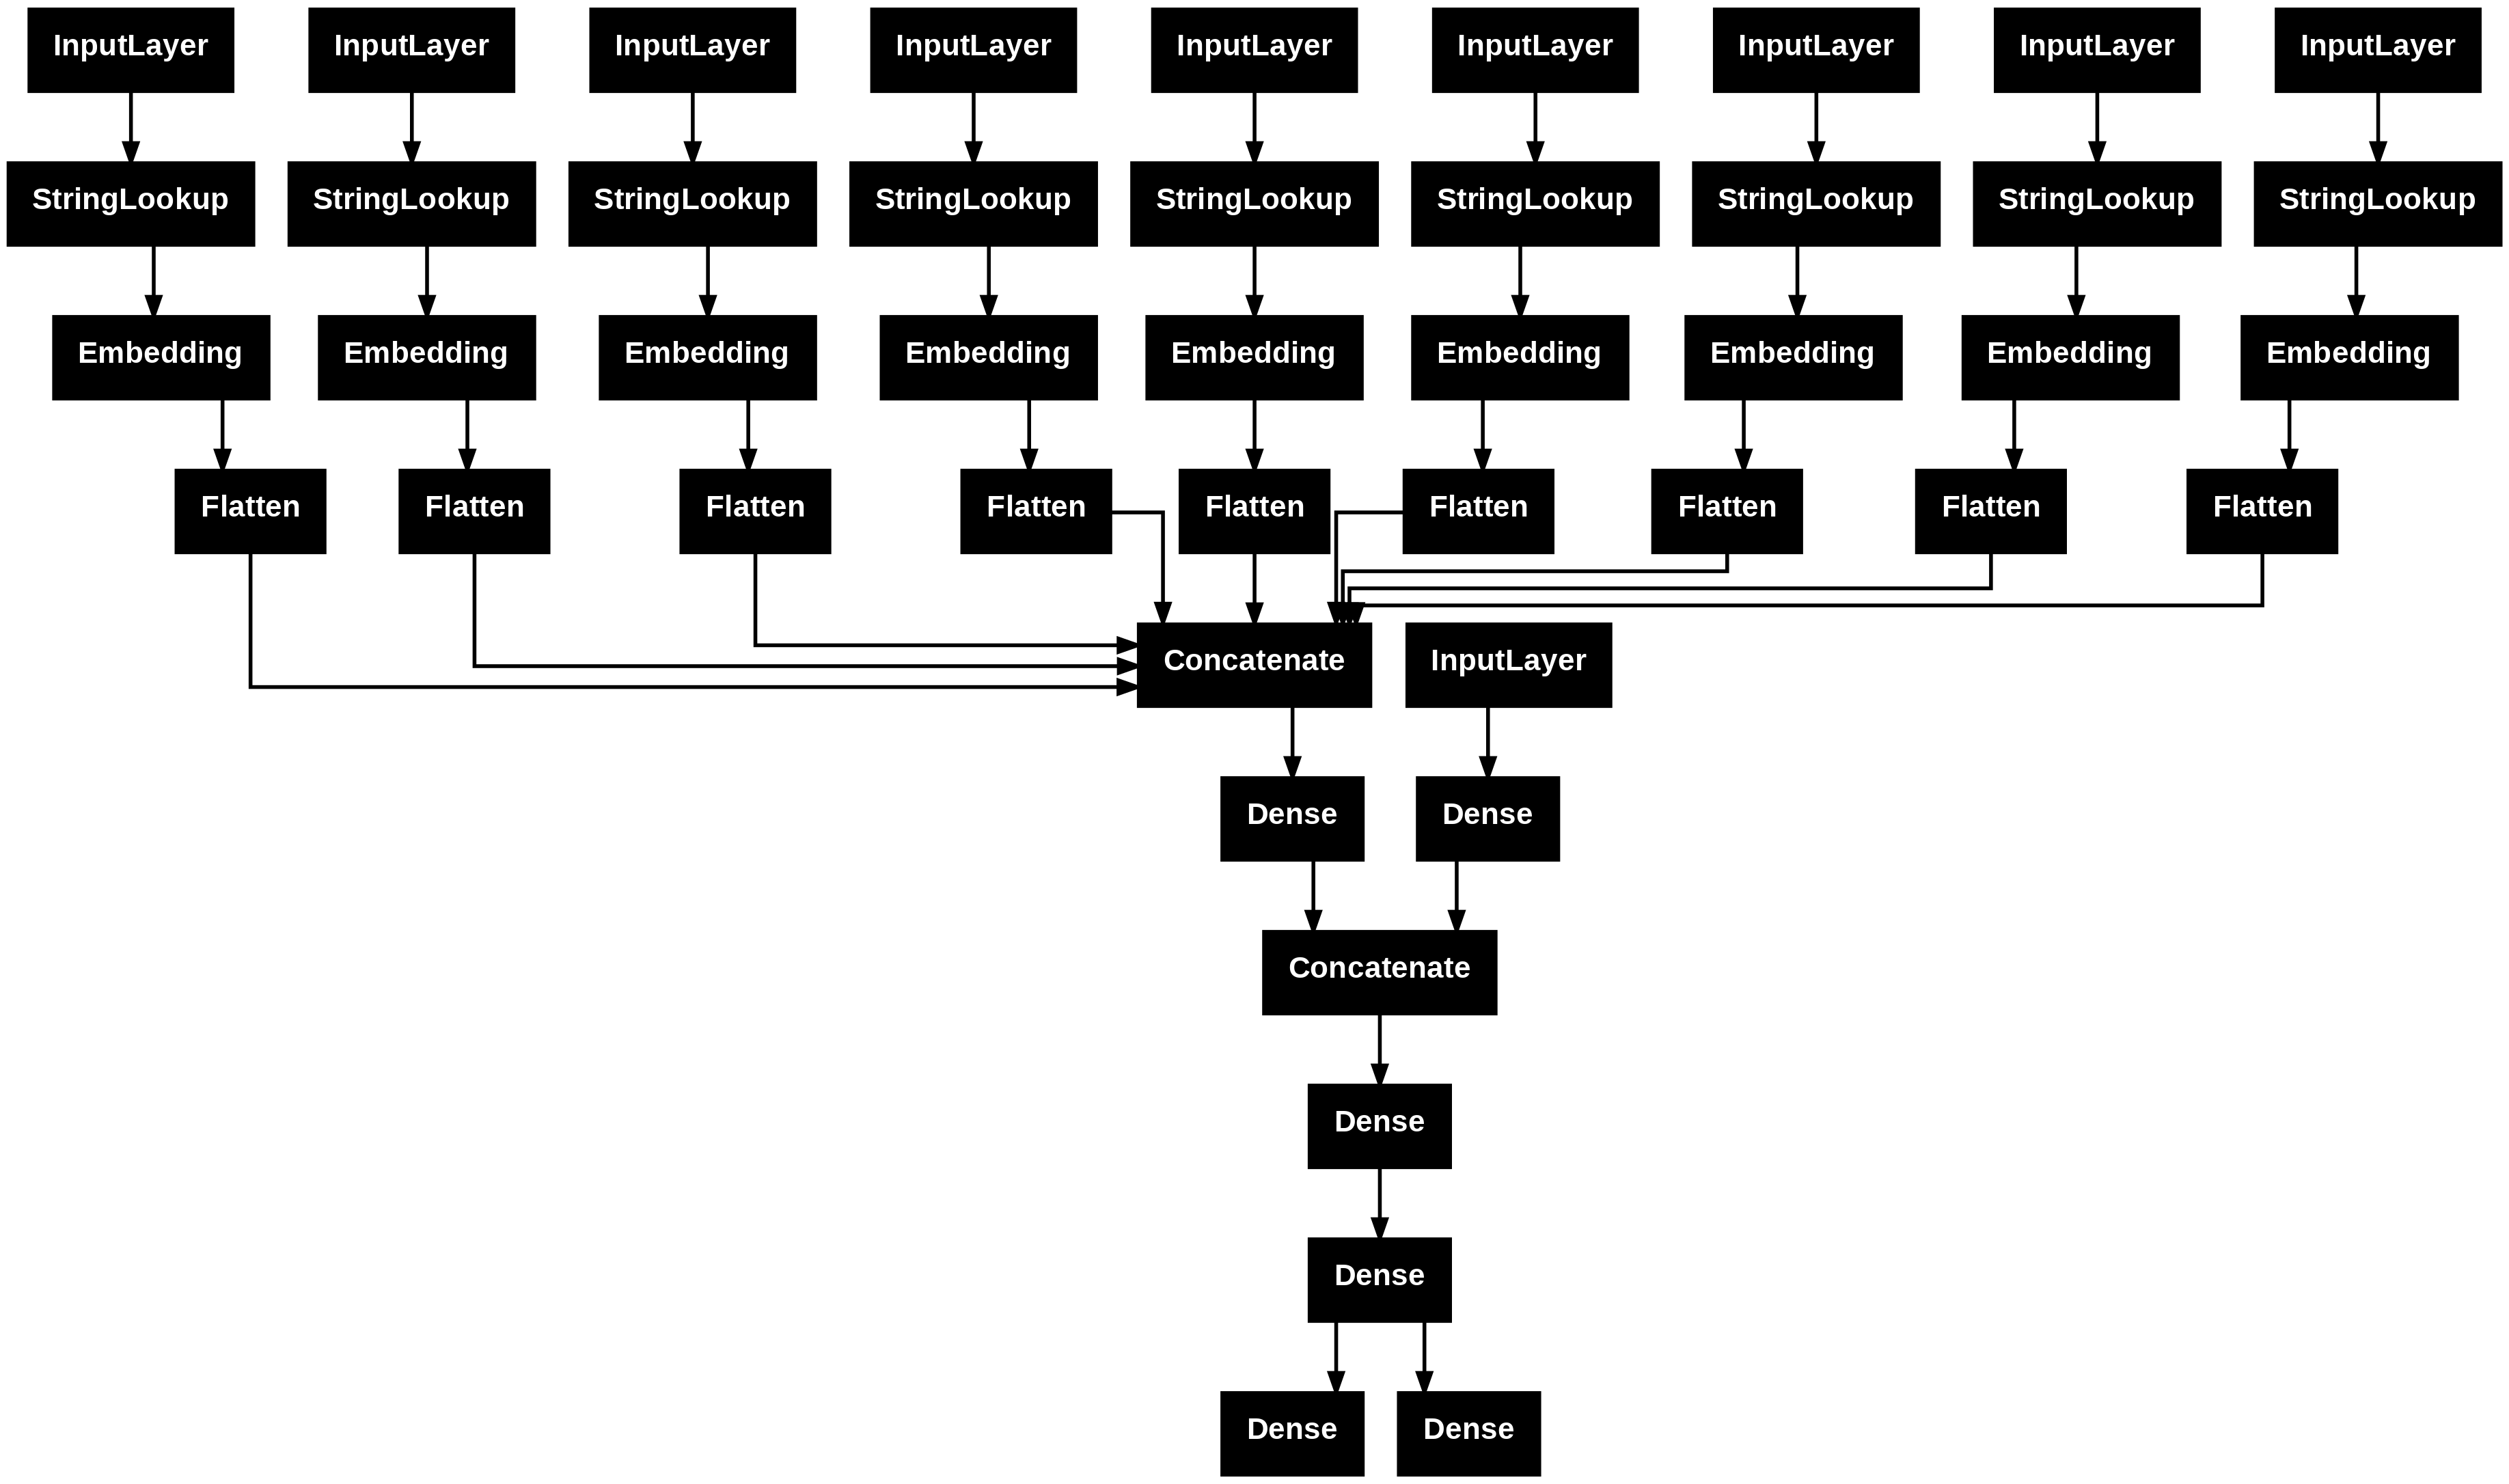

In [116]:
plot_model(model)

In [117]:
model.compile(optimizer='adam', loss={'price': 'mse', 'tier': 'sparse_categorical_crossentropy'}, metrics={'price': 'r2_score', 'tier': 'accuracy'},loss_weights={'price':1,'tier':1})

In [118]:
train_inputs = {
    'numerical_input': X_train_num,
    'area': X_train['area'].astype(str).values,
    'body_type': X_train['body_type'].astype(str).values,
    'brand': X_train['brand'].astype(str).values,
    'condition': X_train['condition'].astype(str).values,
    'fuel_type': X_train['fuel_type'].astype(str).values,
    'model': X_train['model'].astype(str).values,
    'sold_by': X_train['sold_by'].astype(str).values,
    'subarea': X_train['subarea'].astype(str).values,
    'transmission': X_train['transmission'].astype(str).values
}

val_inputs = {
    'numerical_input': X_val_num,
    'area': X_val['area'].astype(str).values,
    'body_type': X_val['body_type'].astype(str).values,
    'brand': X_val['brand'].astype(str).values,
    'condition': X_val['condition'].astype(str).values,
    'fuel_type': X_val['fuel_type'].astype(str).values,
    'model': X_val['model'].astype(str).values,
    'sold_by': X_val['sold_by'].astype(str).values,
    'subarea': X_val['subarea'].astype(str).values,
    'transmission': X_val['transmission'].astype(str).values
}

# Training Strategy

The model was trained using mini-batch gradient descent with:

```text
Epochs: 100
Batch size: 32
Optimizer: Adam
```

To improve training stability and reduce unnecessary training after validation performance stopped improving, two callbacks were used:

### Early Stopping

Early stopping monitored validation loss and restored the weights from the best-performing epoch.

### Reduce Learning Rate on Plateau

The learning rate was reduced when validation performance stopped improving, allowing the model to make smaller updates during later stages of training.


In [119]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)

In [120]:
history = model.fit(
    train_inputs,
    {
        'price': y_train_scaled,
        'tier': y_train_tier_encoded
    },
    validation_data=(
        val_inputs,
        {
            'price': y_val_scaled,
            'tier': y_val_tier_encoded
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 1.3593 - price_loss: 0.7253 - price_r2_score: 0.2737 - tier_accuracy: 0.7548 - tier_loss: 0.6326 - val_loss: 0.4748 - val_price_loss: 0.1109 - val_price_r2_score: 0.7162 - val_tier_accuracy: 0.8507 - val_tier_loss: 0.3636 - learning_rate: 0.0010
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9727 - price_loss: 0.6058 - price_r2_score: 0.3936 - tier_accuracy: 0.8468 - tier_loss: 0.3662 - val_loss: 0.4237 - val_price_loss: 0.0926 - val_price_r2_score: 0.7631 - val_tier_accuracy: 0.8607 - val_tier_loss: 0.3308 - learning_rate: 0.0010
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9194 - price_loss: 0.5758 - price_r2_score: 0.4236 - tier_accuracy: 0.8603 - tier_loss: 0.3430 - val_loss: 0.4019 - val_price_loss: 0.0820 - val_price_r2_score: 0.7900 - val_tier_accuracy: 0.8687 - val_tier_loss: 0.3195 - learning_rate: 0.0010
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.8960 - pric

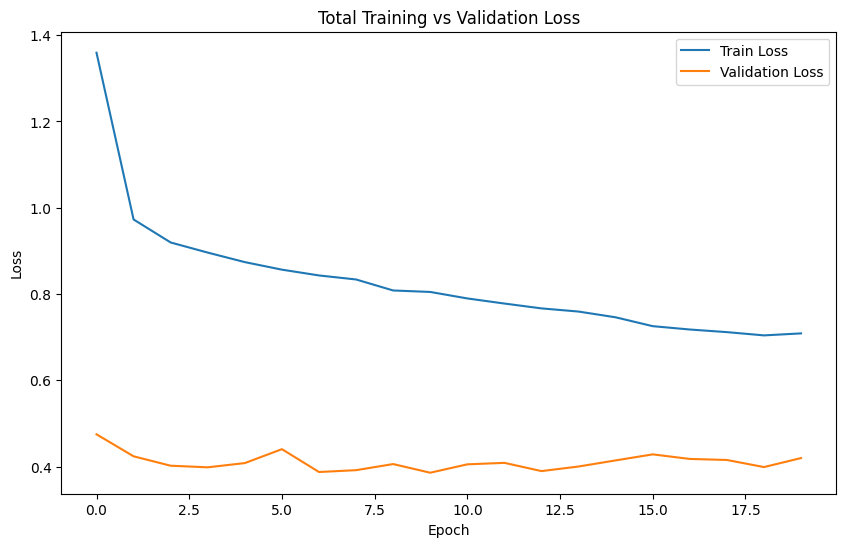

In [121]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Training vs Validation Loss')
plt.legend()
plt.show()

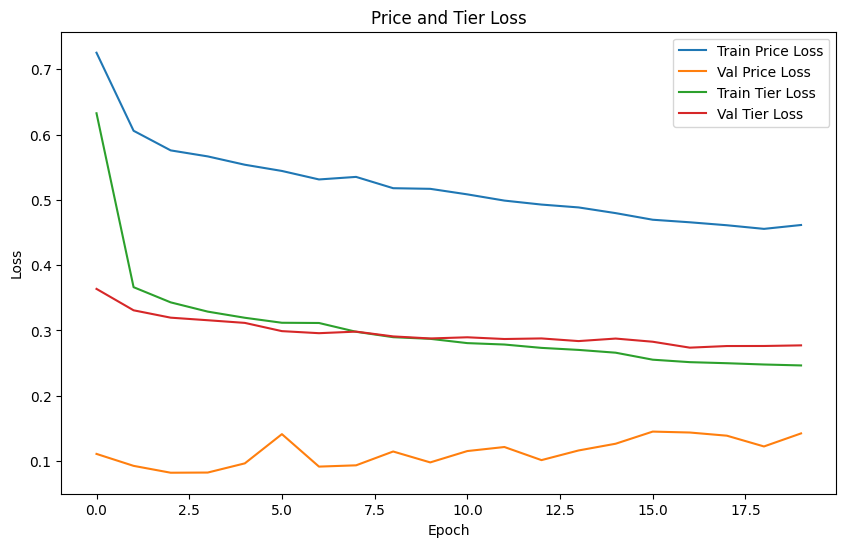

In [122]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['price_loss'], label='Train Price Loss')
plt.plot(history.history['val_price_loss'], label='Val Price Loss')
plt.plot(history.history['tier_loss'], label='Train Tier Loss')
plt.plot(history.history['val_tier_loss'], label='Val Tier Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Price and Tier Loss')
plt.legend()
plt.show()

In [123]:
test_inputs = {
    'numerical_input': X_test_num,
    'area': X_test['area'].astype(str).values,
    'body_type': X_test['body_type'].astype(str).values,
    'brand': X_test['brand'].astype(str).values,
    'condition': X_test['condition'].astype(str).values,
    'fuel_type': X_test['fuel_type'].astype(str).values,
    'model': X_test['model'].astype(str).values,
    'sold_by': X_test['sold_by'].astype(str).values,
    'subarea': X_test['subarea'].astype(str).values,
    'transmission': X_test['transmission'].astype(str).values
}

results = model.evaluate(
    test_inputs,
    {
        'price': y_test_scaled,
        'tier': y_test_tier_encoded
    },
    return_dict=True
)

print(results)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3998 - price_loss: 0.1099 - price_r2_score: 0.8484 - tier_accuracy: 0.8813 - tier_loss: 0.2898
{'loss': 0.3998371958732605, 'price_loss': 0.10992766171693802, 'price_r2_score': 0.8483548760414124, 'tier_accuracy': 0.8813333511352539, 'tier_loss': 0.28982120752334595}


In [124]:
price_pred_scaled, tier_pred_prob = model.predict(test_inputs)

tier_pred = tier_pred_prob.argmax(axis=1)

price_pred = price_scaler.inverse_transform(price_pred_scaled)
y_test_actual = price_scaler.inverse_transform(
    y_test_scaled.reshape(-1, 1)
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [125]:
mae = mean_absolute_error(y_test_scaled, price_pred_scaled)
mse = mean_squared_error(y_test_scaled, price_pred_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, price_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.10672357071862665
RMSE: 0.3318140579713004
R²  : 0.8483549091995537


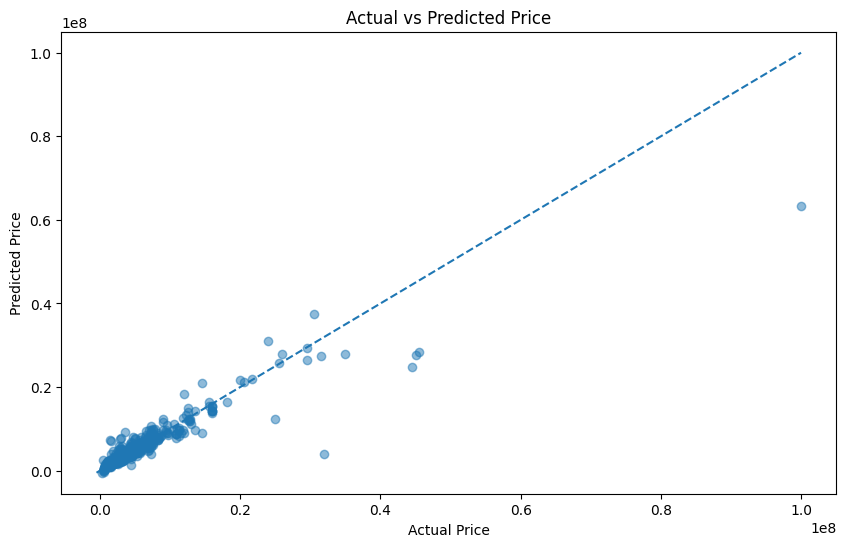

In [126]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test_actual, price_pred, alpha=0.5)

min_val = min(y_test_actual.min(), price_pred.min())
max_val = max(y_test_actual.max(), price_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

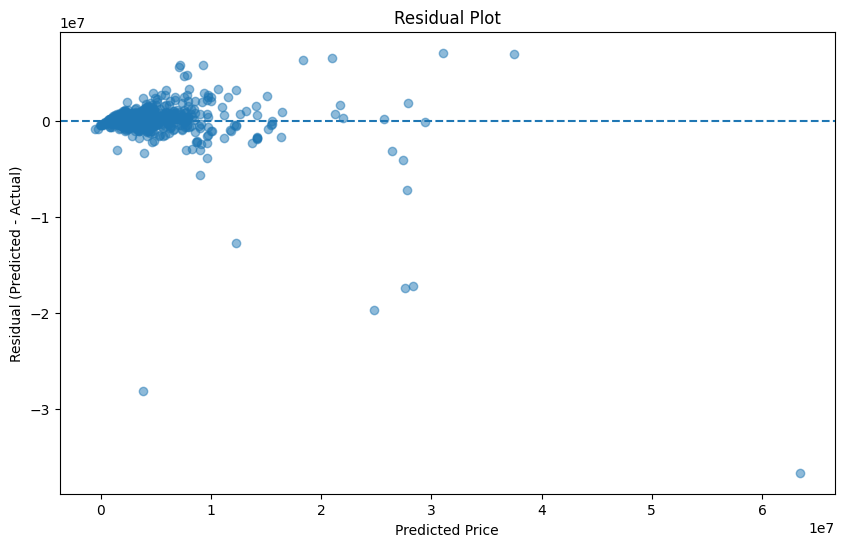

In [127]:
residuals = price_pred.flatten() - y_test_actual.flatten()

plt.figure(figsize=(10, 6))

plt.scatter(price_pred, residuals, alpha=0.5)

plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residual (Predicted - Actual)')
plt.title('Residual Plot')
plt.show()

In [128]:
accuracy = accuracy_score(
    y_test_tier_encoded,
    tier_pred
)

f1 = f1_score(
    y_test_tier_encoded,
    tier_pred,
    average='macro'
)

print("Accuracy:", accuracy)
print("Macro F1:", f1)

Accuracy: 0.8813333333333333
Macro F1: 0.8819094594872573


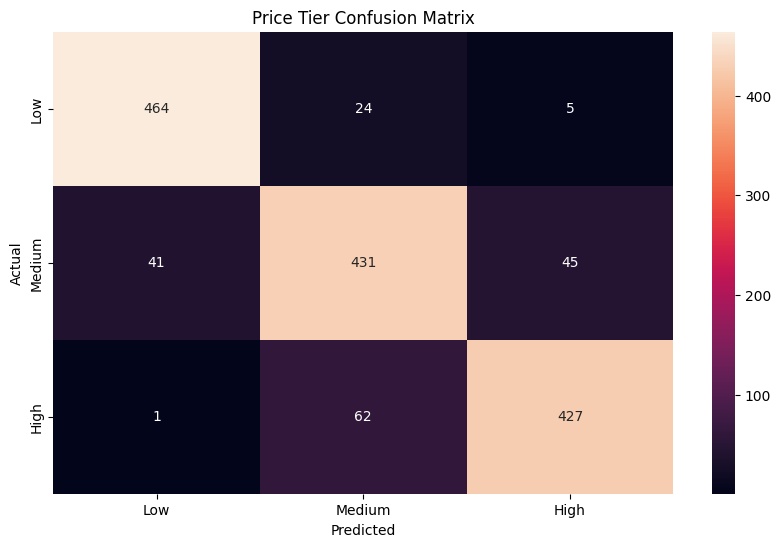

In [129]:
cm = confusion_matrix(
    y_test_tier_encoded,
    tier_pred
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Price Tier Confusion Matrix')
plt.show()

In [130]:
print(
    classification_report(
        y_test_tier_encoded,
        tier_pred,
        target_names=['Low', 'Medium', 'High']
    )
)

              precision    recall  f1-score   support

         Low       0.92      0.94      0.93       493
      Medium       0.83      0.83      0.83       517
        High       0.90      0.87      0.88       490

    accuracy                           0.88      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.88      0.88      0.88      1500



# Baseline vs Deep Learning Model

The final ANN was compared against the baseline models to determine whether the additional complexity of the multi-task neural network resulted in improved performance.



| Model               | Task  | MAE | RMSE |  R² | Accuracy | Macro F1 |
| ------------------- | ----- | --: | ---: | --: | -------: | -------: |
| Linear Regression   | Price | 0.21 |  0.56 | 0.6 |        - |        - |
| Random Forest       | Price | 0.17 |  0.39 | 0.81 |        - |        - |
| Gradient Boosting   | Price | 0.13 |  0.3 | 0.88 |        - |        - |
| Logistic Regression | Tier  |   - |    - |   - |      0.854 |      0.854 |
| Random Forest       | Tier  |   - |    - |   - |      0.889 |      0.889 |
| Gradient Boosting   | Tier  |   - |    - |   - |      0.895 |      0.895 |
| **Multi-task ANN**  | Both  | 0.13 |  0.33 | 0.85 |      0.878 |      0.878 |


# Loss Weight Experiment

Because the regression and classification losses can have different numerical scales, loss weights were experimented with to control the relative importance of each task during training.

| Experiment | Price Weight | Tier Weight | Price R² | Price MAE | Tier Accuracy | Tier F1 |
| ---------- | -----------: | ----------: | -------: | --------: | ------------: | ------: |
| 1          |          1.0 |         1.0 |      0.85 |       0.13 |         0.878 |    0.878|
| 2          |          0.5 |         1.0 |      0.79 |       0.29 |           0.877 |     0.877 |
| 3          |          0.25 |        1.0 |      0.89 |       0.12 |           0.882 |     0.883 |


In [131]:
model.compile(optimizer='adam', 
              loss={'price': 'mse', 'tier': 'sparse_categorical_crossentropy'}, 
              metrics={'price': 'r2_score', 'tier': 'accuracy'},
              loss_weights={'price':0.5,'tier':1}
             )
history = model.fit(
    train_inputs,
    {
        'price': y_train_scaled,
        'tier': y_train_tier_encoded
    },
    validation_data=(
        val_inputs,
        {
            'price': y_val_scaled,
            'tier': y_val_tier_encoded
        }
    ),
    epochs=100,
    batch_size=32,
    verbose=False,
    callbacks=[early_stop,reduce_lr]
)

price_pred_scaled, tier_pred_prob = model.predict(test_inputs)

tier_pred = tier_pred_prob.argmax(axis=1)

price_pred = price_scaler.inverse_transform(price_pred_scaled)
y_test_actual = price_scaler.inverse_transform(
    y_test_scaled.reshape(-1, 1)
)

mae = mean_absolute_error(y_test_scaled, price_pred_scaled)
mse = mean_squared_error(y_test_scaled, price_pred_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, price_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

accuracy = accuracy_score(
    y_test_tier_encoded,
    tier_pred
)

f1 = f1_score(
    y_test_tier_encoded,
    tier_pred,
    average='macro'
)

print("Accuracy:", accuracy)
print("Macro F1:", f1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
MAE : 0.11410513296059302
RMSE: 0.30365226466759476
R²  : 0.8730034739936696
Accuracy: 0.8873333333333333
Macro F1: 0.8878309239506722


In [132]:
model.compile(optimizer='adam', 
              loss={'price': 'mse', 'tier': 'sparse_categorical_crossentropy'}, 
              metrics={'price': 'r2_score', 'tier': 'accuracy'},
              loss_weights={'price':0.25,'tier':1}
             )
history = model.fit(
    train_inputs,
    {
        'price': y_train_scaled,
        'tier': y_train_tier_encoded
    },
    validation_data=(
        val_inputs,
        {
            'price': y_val_scaled,
            'tier': y_val_tier_encoded
        }
    ),
    epochs=100,
    batch_size=32,
    verbose=False,
    callbacks=[early_stop,reduce_lr]
)

price_pred_scaled, tier_pred_prob = model.predict(test_inputs)

tier_pred = tier_pred_prob.argmax(axis=1)

price_pred = price_scaler.inverse_transform(price_pred_scaled)
y_test_actual = price_scaler.inverse_transform(
    y_test_scaled.reshape(-1, 1)
)

mae = mean_absolute_error(y_test_scaled, price_pred_scaled)
mse = mean_squared_error(y_test_scaled, price_pred_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, price_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

accuracy = accuracy_score(
    y_test_tier_encoded,
    tier_pred
)

f1 = f1_score(
    y_test_tier_encoded,
    tier_pred,
    average='macro'
)

print("Accuracy:", accuracy)
print("Macro F1:", f1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
MAE : 0.11471959546128824
RMSE: 0.2990962741154036
R²  : 0.8767857881495433
Accuracy: 0.8826666666666667
Macro F1: 0.8824568624660166


# Final Findings

```text
The baseline experiments showed that Gradient Boosting performed best among the traditional machine learning models for both tasks.

For price prediction, Gradient Boosting achieved an MAE of 0.13, RMSE of 0.30 and R² of 0.88, outperforming Random Forest and Linear Regression.

For price-tier classification, Gradient Boosting achieved the highest performance with an accuracy and Macro F1-score of 0.895.

The final Multi-Task ANN achieved an MAE of 0.13, RMSE of 0.33 and R² of 0.85 for price prediction, while achieving 88% accuracy and 0.88 Macro F1-score for price-tier classification.

Although the Multi-Task ANN did not outperform Gradient Boosting on either individual task, it successfully performed both regression and classification simultaneously using a single model. This was the primary architectural objective of the project.

The results also demonstrate an important trade-off in multi-task learning: sharing a common representation between related tasks does not necessarily guarantee better performance than specialized single-task models. However, it allows multiple prediction objectives to be handled within one unified architecture.
```

----------